# 03 - EDA and Dissertation Figure Set

Generates the full figure set for the dissertation in one pass.

**Scope note.** Sections 1-2 are exploratory analysis of the training partition. Sections 3-6 read model, ablation, lead-time and tier artefacts to build the Results and Methodology figures. Every downstream cell guards its inputs: if an artefact CSV is present it is used, otherwise the locked verified value is used and the cell prints which source it took. Figures needing raw predictions skip cleanly if those are unavailable.

**Design standard.** One red for dissolved/risk, one blue for active/safe, no third accent, no 3D, bars from zero, base-rate reference line on category charts, source note under each figure, 300 dpi PNG plus SVG for vector editing.

**Sections**
1. Cohort and data quality
2. Feature signal (EDA)
3. Data sources and population (Ch3)
4. Methodology diagrams (Ch4)
5. Results (Ch5)
6. Integration (Ch6)

In [24]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyBboxPatch, FancyArrowPatch, Rectangle

warnings.filterwarnings("ignore")

from src.config import PROCESSED_FILES, OUTPUTS_DIR, FIGURES_DIR, TABLES_DIR, FEATURE_COLS, RAW_FILES, MODELS_DIR

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

CHARCOAL = "#2E2E38"
ACCENT = "#FFE600"
RISK = "#E0C400"
SAFE = "#9897A9"
GREY = "#747480"
LIGHT = "#C4C4CD"
MID = "#9897A9"
REFLINE = "#2E2E38"
HUE_A = "#FFE600"
HUE_B = "#747480"
HUE_C = "#C8A400"

from matplotlib.colors import LinearSegmentedColormap
EY_SEQ = LinearSegmentedColormap.from_list("ey_seq",
    ["#FFFBE0", "#FFE600", "#C8A400", "#6E5E14", "#2E2E38"])
EY_DIV = LinearSegmentedColormap.from_list("ey_div",
    ["#2E2E38", "#9897A9", "#FFFFFF", "#FFE600", "#7A6800"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300,
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": "#2E2E38", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E7E7EA", "grid.linewidth": 0.8,
    "legend.frameon": False,
    "axes.axisbelow": True,   # gridlines behind bars, not through them
})

SHOW_SOURCE_NOTES = False

SAVE_SVG = False

FIG_LOG = []
FIG_NOTES = []
_PENDING_NOTE = {"text": None}

def add_source(fig, text):
    """Record the caveat/provenance note for the figure about to be saved."""
    _PENDING_NOTE["text"] = " ".join(str(text).split())
    if SHOW_SOURCE_NOTES:
        fig.text(0.01, -0.02, text, ha="left", va="top", fontsize=8, color=GREY)

def save_fig(fig, name, svg=None):
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight")
    if SAVE_SVG if svg is None else svg:
        fig.savefig(FIGURES_DIR / f"{name}.svg", bbox_inches="tight")
    FIG_LOG.append(name)
    FIG_NOTES.append({"figure": name, "caption_note": _PENDING_NOTE["text"] or ""})
    _PENDING_NOTE["text"] = None
    print(f"  saved: {name}")

PROC_DIR = Path(PROCESSED_FILES["test_set"]).parent
SEARCH_DIRS = [TABLES_DIR, OUTPUTS_DIR, OUTPUTS_DIR / "tables", OUTPUTS_DIR / "nlp",
               PROC_DIR, PROC_DIR / "audit", PROJECT_ROOT]

def try_read(filename):
    """Look for a CSV across known output dirs. Return DataFrame or None."""
    for d in SEARCH_DIRS:
        try:
            p = Path(d) / filename
            if p.exists():
                return pd.read_csv(p)
        except Exception:
            continue
    return None

def pick_col(df, *candidates):
    """Return the first matching column name (case-insensitive), else None."""
    if df is None:
        return None
    low = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in low:
            return low[cand.lower()]
    return None

train_df = pd.read_csv(PROCESSED_FILES["train_set"], low_memory=False)
test_df = pd.read_csv(PROCESSED_FILES["test_set"], low_memory=False)

n_train, n_test = len(train_df), len(test_df)
base_rate = train_df["label"].mean()
test_rate = test_df["label"].mean()
imbalance = (train_df["label"] == 0).sum() / max((train_df["label"] == 1).sum(), 1)

print(f"Train: {n_train:,}  dissolved={base_rate:.2%}")
print(f"Test : {n_test:,}  dissolved={test_rate:.2%}")
print(f"Imbalance: {imbalance:.1f}:1")

SRC = f"Source: CRO filing metadata, training partition (n={n_train:,})."

Train: 98,926  dissolved=6.69%
Test : 94,421  dissolved=4.07%
Imbalance: 13.9:1


## Section 1 - Cohort and data quality

### Figure 1.1 - Partition sizes and dissolution rate (Magnitude)

### Figure 1.2 - Feature completeness (Distribution)

Share of missing values per feature, showing which blocks depend on external coverage.

  saved: fig_01_completeness


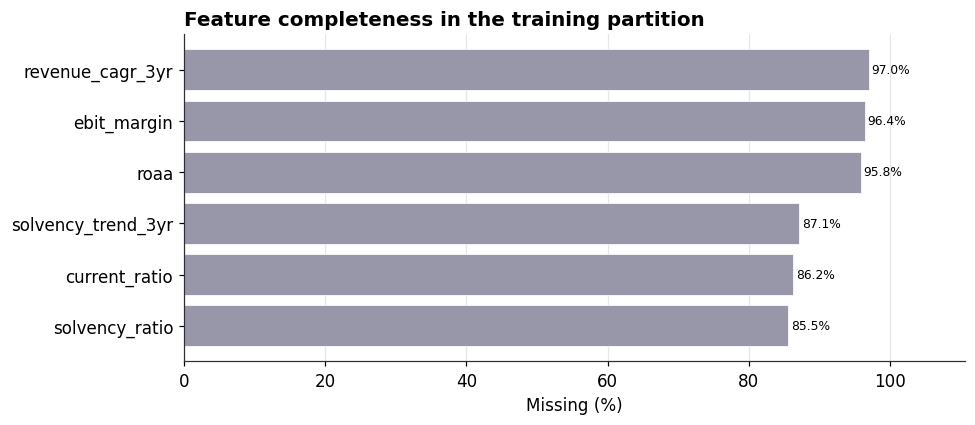

In [25]:
feat_cols = [f for f in FEATURE_COLS if f in train_df.columns]
miss = (train_df[feat_cols].isna().mean().sort_values(ascending=False))
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(9, max(4, 0.28*len(miss)+1)))
if len(miss):
    ax.barh(miss.index[::-1], miss.values[::-1]*100, color=MID, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Missing (%)")
    for i, v in enumerate(miss.values[::-1]):
        ax.text(v*100+0.4, i, f"{v:.1%}", va="center", fontsize=8)
    ax.margins(x=0.14)
else:
    ax.text(0.5, 0.5, "No missing values across modelled features", ha="center",
            va="center", transform=ax.transAxes, fontsize=12, color=GREY)
    ax.set_axis_off()
ax.set_title("Feature completeness in the training partition", loc="left")
ax.grid(axis="y", visible=False)
add_source(fig, SRC + "  Features with zero missing values omitted.")
plt.tight_layout()
save_fig(fig, "fig_01_completeness")
plt.show()
pd.DataFrame({"feature": miss.index, "missing_share": miss.values}).to_csv(
    TABLES_DIR / "feature_missingness.csv", index=False)

## Section 2 - Feature signal

Effect sizes and significance for every feature, saved to `feature_effect_sizes.csv`.

In [26]:
from scipy.stats import mannwhitneyu

def cohen_d(a, b):
    a, b = a.dropna(), b.dropna()
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return 0.0
    pooled = np.sqrt(((na-1)*a.std()**2 + (nb-1)*b.std()**2) / (na+nb-2))
    return 0.0 if pooled == 0 else (a.mean()-b.mean())/pooled

alpha_bonf = 0.05 / len(feat_cols)
rows = []
for f in feat_cols:
    dis = train_df.loc[train_df["label"] == 1, f]
    act = train_df.loc[train_df["label"] == 0, f]
    d = cohen_d(dis, act)
    try:
        _, p = mannwhitneyu(dis.dropna(), act.dropna(), alternative="two-sided")
    except ValueError:
        p = np.nan
    rows.append({"feature": f, "cohen_d": round(d, 4), "abs_d": round(abs(d), 4),
                 "p_value": p,
                 "bonferroni_sig": bool(p < alpha_bonf) if pd.notna(p) else False})

effect_df = pd.DataFrame(rows).sort_values("abs_d", ascending=False).reset_index(drop=True)
effect_df.to_csv(TABLES_DIR / "feature_effect_sizes.csv", index=False)
print(f"Bonferroni alpha = {alpha_bonf:.2e}")
print(f"Significant after Bonferroni: {int(effect_df['bonferroni_sig'].sum())} / {len(effect_df)}")

pars = try_read("parsimony_top15.csv")
fcol = pick_col(pars, "feature", "features", "name")
TOP15, TOP15_SRC = None, ""
if pars is not None and fcol is not None:
    cand = [f for f in pars[fcol].astype(str).tolist() if f in train_df.columns]
    if len(cand) >= 10:
        TOP15, TOP15_SRC = cand[:15], "parsimony_top15.csv (SHAP ranking)"
if TOP15 is None:
    TOP15 = effect_df.head(15)["feature"].tolist()
    TOP15_SRC = "top 15 by |Cohen's d| (parsimony ranking unavailable)"
print(f"Top-15 feature set from: {TOP15_SRC}")

Bonferroni alpha = 5.95e-04
Significant after Bonferroni: 64 / 84
Top-15 feature set from: parsimony_top15.csv (SHAP ranking)


### Figure 2.1 - Feature effect sizes (Deviation)

Standardised mean difference, dissolved minus active, top 25 by magnitude. Red points to signals stronger in dissolved companies, blue stronger in active. Asterisk marks Bonferroni significance.

  saved: fig_02_effect_sizes


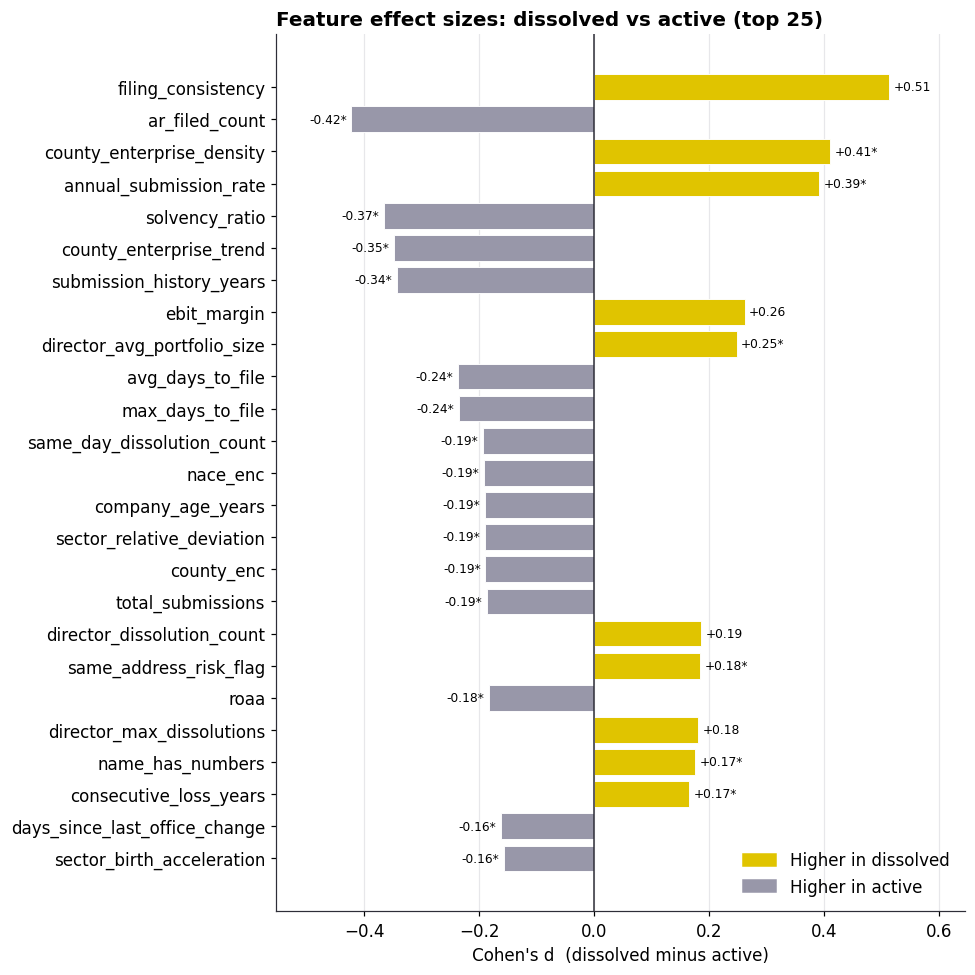

In [27]:
TOP_N = 25
top = effect_df.head(TOP_N).iloc[::-1]
colors = [RISK if d > 0 else SAFE for d in top["cohen_d"]]

fig, ax = plt.subplots(figsize=(9, 9))
bars = ax.barh(top["feature"], top["cohen_d"], color=colors, edgecolor="white", linewidth=0.6)
ax.axvline(0, color=REFLINE, linewidth=1.0)
ax.set_xlabel("Cohen's d  (dissolved minus active)")
ax.set_title(f"Feature effect sizes: dissolved vs active (top {TOP_N})", loc="left")
ax.grid(axis="y", visible=False)
for bar, (_, r) in zip(bars, top.iterrows()):
    x = bar.get_width()
    ax.text(x + (0.008 if x >= 0 else -0.008), bar.get_y()+bar.get_height()/2,
            f"{r['cohen_d']:+.2f}" + ("*" if r["bonferroni_sig"] else ""),
            va="center", ha="left" if x >= 0 else "right", fontsize=8)
ax.legend(handles=[Patch(color=RISK, label="Higher in dissolved"),
                   Patch(color=SAFE, label="Higher in active")], loc="lower right")
ax.margins(x=0.14)
add_source(fig, SRC + "  * Bonferroni-significant. Full table: feature_effect_sizes.csv")
plt.tight_layout()
save_fig(fig, "fig_02_effect_sizes")
plt.show()

### Distributions of the strongest drivers (Distribution)

Six panels at page width. The separation between active and dissolved is visible, and so is the overlap: this is the honest picture of why average precision is 0.63 rather than near-perfect. Effect sizes for every feature are in the figure above and in `feature_effect_sizes.csv`.

  saved: fig_03_top_feature_distributions


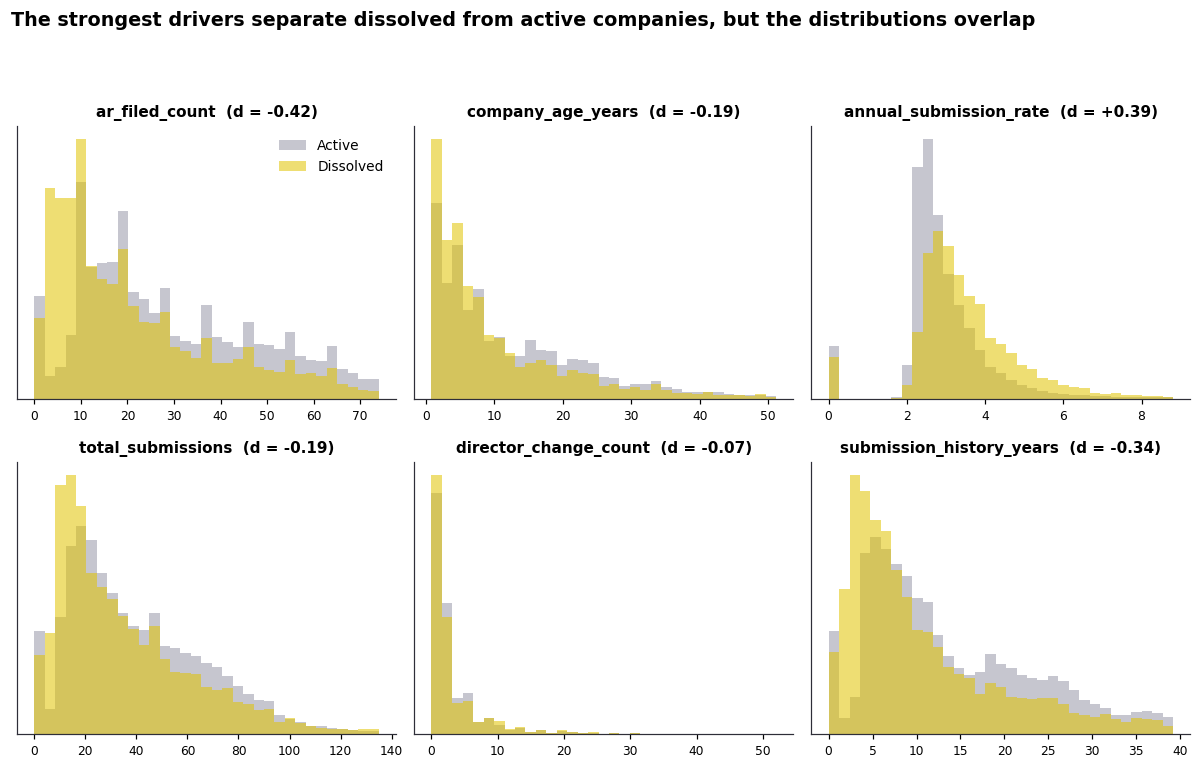

In [28]:
SHOW_N = 6
continuous = [f for f in TOP15
              if f in train_df.columns and train_df[f].dropna().nunique() > 2]
panel_feats = continuous[:SHOW_N]
skipped = [f for f in TOP15[:SHOW_N] if f not in panel_feats]
if skipped:
    print(f"Excluded from the distribution panels (binary; see the odds-ratio figure): {skipped}")

if not panel_feats:
    print("No continuous features available to plot; figure skipped.")
else:
    ncol = 3
    nrow = int(np.ceil(len(panel_feats)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(11, 3.1*nrow + 0.9), squeeze=False)
    fig.suptitle("The strongest drivers separate dissolved from active companies, "
                 "but the distributions overlap",
                 x=0.01, ha="left", fontsize=12.5, fontweight="bold")
    for ax, feat in zip(axes.flat, panel_feats):
        act = train_df.loc[train_df["label"] == 0, feat].dropna()
        dis = train_df.loc[train_df["label"] == 1, feat].dropna()
        if len(act) == 0 or len(dis) == 0:
            ax.set_visible(False); continue
        lo = min(act.quantile(0.01), dis.quantile(0.01))
        hi = max(act.quantile(0.99), dis.quantile(0.99))
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo, hi = float(min(act.min(), dis.min())), float(max(act.max(), dis.max()))
        if lo == hi:
            hi = lo + 1
        bins = np.linspace(lo, hi, 34)
        ax.hist(act, bins=bins, density=True, color=SAFE, alpha=0.55, label="Active")
        ax.hist(dis, bins=bins, density=True, color=RISK, alpha=0.55, label="Dissolved")
        ds = effect_df.loc[effect_df["feature"] == feat, "cohen_d"]
        dt = f"  (d = {ds.values[0]:+.2f})" if len(ds) else ""
        ax.set_title(feat + dt, fontsize=10)
        ax.set_yticks([])
        ax.tick_params(axis="x", labelsize=8)
        ax.grid(axis="x", visible=False)
    for ax in axes.flat[len(panel_feats):]:
        ax.set_visible(False)
    axes.flat[0].legend(loc="upper right", fontsize=9)
    add_source(fig, SRC + f"  The {len(panel_feats)} strongest continuous drivers, from "
                    f"{TOP15_SRC}. Binary flags excluded. Densities normalised; axes clipped to "
                    f"the 1st-99th percentile. Effect sizes for all {len(effect_df)} features: "
                    f"feature_effect_sizes.csv.")
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    save_fig(fig, "fig_03_top_feature_distributions")
    plt.show()

### Figure 2.6 - Binary flag odds ratios (Deviation)

Fisher's exact odds ratios with 95% intervals, on a log scale. Right of 1.0 raises the odds of dissolution, left lowers them. An interval crossing 1.0 is a flag whose direction the data does not establish.

  saved: fig_04_binary_odds


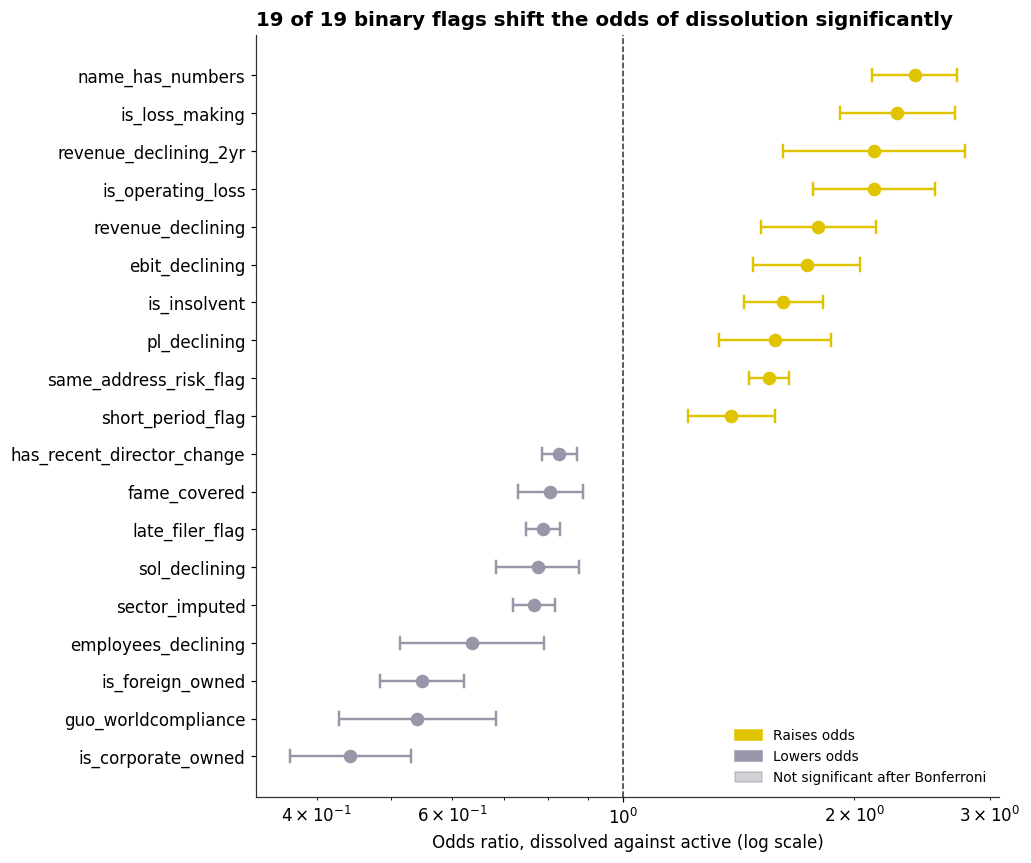

In [29]:
from scipy.stats import fisher_exact

BINARY = ["late_filer_flag", "short_period_flag", "same_address_risk_flag",
          "is_on_strike_off_list", "fame_covered", "is_corporate_owned", "is_foreign_owned",
          "guo_worldcompliance", "is_loss_making", "is_insolvent", "pl_declining",
          "sol_declining", "revenue_declining", "revenue_declining_2yr", "is_operating_loss",
          "ebit_declining", "employees_declining", "name_has_numbers", "sector_imputed",
          "has_recent_director_change"]
rows = []
for f in [b for b in BINARY if b in train_df.columns]:
    dis = train_df.loc[train_df["label"] == 1, f].fillna(0)
    act = train_df.loc[train_df["label"] == 0, f].fillna(0)
    a, b_ = int(dis.sum()), int((dis == 0).sum())
    c, d_ = int(act.sum()), int((act == 0).sum())
    if min(a, b_, c, d_) == 0:
        continue
    try:
        _, p = fisher_exact([[a, b_], [c, d_]], alternative="two-sided")
    except ValueError:
        continue
    orr = (a*d_)/(b_*c)
    if not np.isfinite(orr) or orr <= 0:
        continue
    se = np.sqrt(1/a + 1/b_ + 1/c + 1/d_)
    rows.append({"feature": f, "odds_ratio": orr,
                 "ci_lo": float(np.exp(np.log(orr) - 1.96*se)),
                 "ci_hi": float(np.exp(np.log(orr) + 1.96*se)),
                 "n_dissolved_with_flag": a, "n_active_with_flag": c,
                 "p_value": p, "bonferroni_sig": bool(p < alpha_bonf)})
bin_df = pd.DataFrame(rows).sort_values("odds_ratio")
bin_df.round(4).to_csv(TABLES_DIR / "binary_feature_tests.csv", index=False)

if len(bin_df):
    fig, ax = plt.subplots(figsize=(9.5, max(5, 0.42*len(bin_df))))
    for i, (_, r) in enumerate(bin_df.iterrows()):
        col = RISK if r["odds_ratio"] > 1 else SAFE
        al = 1.0 if r["bonferroni_sig"] else 0.32
        ax.plot([r["ci_lo"], r["ci_hi"]], [i, i], color=col, alpha=al, linewidth=1.6,
                zorder=2, solid_capstyle="butt")
        for x in (r["ci_lo"], r["ci_hi"]):
            ax.plot([x, x], [i-0.16, i+0.16], color=col, alpha=al, linewidth=1.6, zorder=2)
        ax.scatter(r["odds_ratio"], i, color=col, alpha=al, s=62, zorder=4)
    ax.axvline(1.0, color=REFLINE, linestyle="--", linewidth=1.0, zorder=1)
    ax.set_yticks(range(len(bin_df)))
    ax.set_yticklabels(bin_df["feature"])
    ax.set_xscale("log")
    ax.set_xlabel("Odds ratio, dissolved against active (log scale)")
    n_sig = int(bin_df["bonferroni_sig"].sum())
    ax.set_title(f"{n_sig} of {len(bin_df)} binary flags shift the odds of dissolution "
                 f"significantly", loc="left")
    ax.grid(axis="y", visible=False)
    ax.legend(handles=[Patch(color=RISK, label="Raises odds"),
                       Patch(color=SAFE, label="Lowers odds"),
                       Patch(color=GREY, alpha=0.32, label="Not significant after Bonferroni")],
              loc="lower right", fontsize=9)
    add_source(fig, SRC + "  Fisher's exact test for the p-value; whiskers are the Woolf "
                          "95% interval on the log odds ratio. An interval crossing 1.0 is a "
                          "flag whose direction the data does not establish. A log axis is "
                          "used because an odds ratio of 4 and one of 0.25 are the same "
                          "magnitude in opposite directions.")
    plt.tight_layout()
    save_fig(fig, "fig_04_binary_odds")
    plt.show()
else:
    print("No binary features available; skipped.")


### Figure 2.7 - Dissolution rate by sector (Ranking)

NACE mapping: 98,902 of 98,926 companies mapped to a section (100.0%); 24 unmappable or missing.
Distinct sections present: ['C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U']
Suppressed 1 section(s) with fewer than 50 companies: ['T']

BRA31 statistics available (label | unit):
   Active Enterprises  |  number  (3960 rows)
   Employees in Active Enterprises  |  number  (3960 rows)
   Employees in Birthed Enterprises  |  number  (3960 rows)
   Enterprise Births  |  number  (3960 rows)
   Persons Engaged in Active Enterprises  |  number  (3960 rows)
   Persons Engaged in Birthed Enterprises  |  number  (3960 rows)

BRA31 selected: label='Active Enterprises', unit='Number', year=2023, 16 sections.
National total from selected rows: 381,982 active enterprises.
Plausibility check passed.
  saved: fig_05_sector_risk


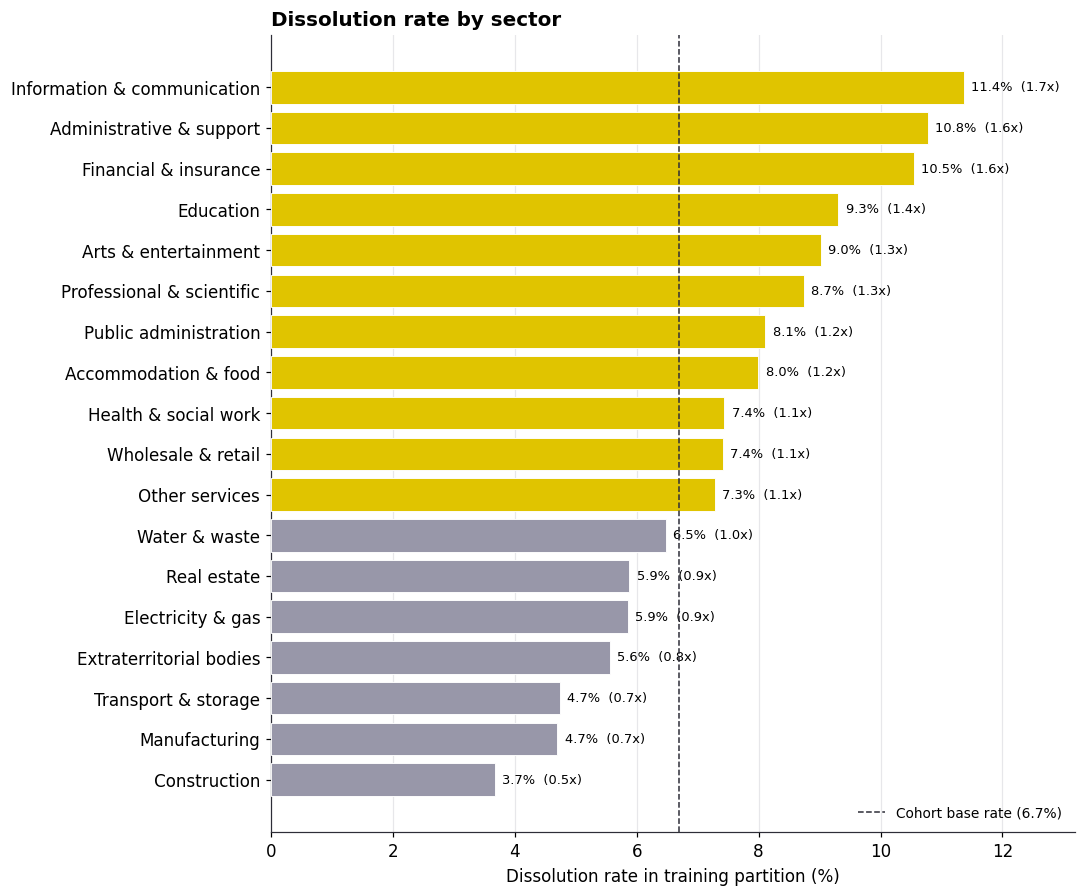

In [30]:
_NACE_RANGES = [
    (1, 3, "A"), (5, 9, "B"), (10, 33, "C"), (35, 35, "D"), (36, 39, "E"),
    (41, 43, "F"), (45, 47, "G"), (49, 53, "H"), (55, 56, "I"), (58, 63, "J"),
    (64, 66, "K"), (68, 68, "L"), (69, 75, "M"), (77, 82, "N"), (84, 84, "O"),
    (85, 85, "P"), (86, 88, "Q"), (90, 93, "R"), (94, 96, "S"), (97, 98, "T"),
    (99, 99, "U"),
]
VALID_SECTIONS = set("ABCDEFGHIJKLMNOPQRSTU")

def nace_section(code):
    """Return the NACE Rev.2 section letter for a code, or None if unmappable."""
    if pd.isna(code):
        return None
    s = str(code).strip().replace(".", "").replace(" ", "").upper()
    if not s:
        return None
    if s[0].isalpha():
        return s[0] if s[0] in VALID_SECTIONS else None
    if len(s) < 2 or not s[:2].isdigit():
        return None
    d = int(s[:2])
    for lo, hi, sec in _NACE_RANGES:
        if lo <= d <= hi:
            return sec
    return None

if "nace_v2_code" in train_df.columns:
    train_df["_sec"] = train_df["nace_v2_code"].apply(nace_section)
else:
    train_df["_sec"] = None

n_mapped = train_df["_sec"].notna().sum()
print(f"NACE mapping: {n_mapped:,} of {len(train_df):,} companies mapped to a section "
      f"({n_mapped/len(train_df):.1%}); {len(train_df)-n_mapped:,} unmappable or missing.")
print(f"Distinct sections present: {sorted(train_df['_sec'].dropna().unique())}")

MIN_N = 50
sec = (train_df.dropna(subset=["_sec"])
       .groupby("_sec").agg(n=("label", "count"), dissolved=("label", "sum"))
       .reset_index())
sec["rate"] = sec["dissolved"] / sec["n"]
small = sec[sec["n"] < MIN_N]
if len(small):
    print(f"Suppressed {len(small)} section(s) with fewer than {MIN_N} companies: {sorted(small['_sec'])}")
sec = sec[sec["n"] >= MIN_N]

NACE_NAMES = {"A": "Agriculture, forestry & fishing", "B": "Mining & quarrying",
    "C": "Manufacturing", "D": "Electricity & gas", "E": "Water & waste",
    "F": "Construction", "G": "Wholesale & retail", "H": "Transport & storage",
    "I": "Accommodation & food", "J": "Information & communication",
    "K": "Financial & insurance", "L": "Real estate", "M": "Professional & scientific",
    "N": "Administrative & support", "O": "Public administration", "P": "Education",
    "Q": "Health & social work", "R": "Arts & entertainment", "S": "Other services",
    "T": "Household employers", "U": "Extraterritorial bodies"}

IE_ENTERPRISE_RANGE = (150_000, 600_000)   # Ireland has roughly 330k active enterprises
EXCLUDE_TOKENS = ("persons", "employee", "turnover", "wage", "salary",
                  "value added", "gva", "births", "deaths", "survival", "rate")

bra31_active = {}
try:
    bra = pd.read_csv(RAW_FILES.get("bra31"), encoding="utf-8-sig", low_memory=False)
    bra.columns = [c.strip().lower().replace(" ", "_") for c in bra.columns]
    bra["value"] = pd.to_numeric(bra["value"], errors="coerce")
    bra["year"] = pd.to_numeric(bra["year"], errors="coerce").fillna(0).astype(int)

    lab = bra["statistic_label"].astype(str).str.strip()
    unit = bra["unit"].astype(str).str.strip().str.lower() if "unit" in bra.columns else pd.Series("", index=bra.index)
    print("\nBRA31 statistics available (label | unit):")
    for (l, u), cnt in bra.assign(_l=lab, _u=unit).groupby(["_l", "_u"]).size().items():
        print(f"   {l}  |  {u}  ({cnt} rows)")

    is_count_unit = unit.str.contains("number", na=False)
    ll = lab.str.lower()
    is_enterprise_count = (ll == "active enterprises")
    if not is_enterprise_count.any():
        is_enterprise_count = ll.str.contains("active enterprises", na=False) & \
                              ~ll.str.contains("|".join(EXCLUDE_TOKENS), na=False)

    m = (is_enterprise_count & is_count_unit
         & bra["employment_size"].astype(str).str.contains("All persons engaged", case=False, na=False)
         & bra["value"].notna())
    sub = bra[m].copy()
    sub["section"] = sub["activity"].astype(str).str.extract(r"\(([A-Z])\)$")
    sub = sub[sub["section"].notna()]

    if len(sub):
        latest_yr = int(sub["year"].max())
        latest = sub[sub["year"] == latest_yr]
        dup = latest.duplicated(subset=["section"]).sum()
        if dup:
            print(f"   Warning: {dup} duplicate section rows after filtering; taking the maximum per section.")
            counts = latest.groupby("section")["value"].max()
        else:
            counts = latest.groupby("section")["value"].sum()
        total = float(counts.sum())
        print(f"\nBRA31 selected: label='{latest['statistic_label'].iloc[0]}', "
              f"unit='{latest['unit'].iloc[0] if 'unit' in latest else 'n/a'}', year={latest_yr}, "
              f"{len(counts)} sections.")
        print(f"National total from selected rows: {total:,.0f} active enterprises.")
        if IE_ENTERPRISE_RANGE[0] <= total <= IE_ENTERPRISE_RANGE[1]:
            bra31_active = counts.to_dict()
            print("Plausibility check passed.")
        else:
            print(f"PLAUSIBILITY CHECK FAILED: {total:,.0f} is outside the expected range "
                  f"{IE_ENTERPRISE_RANGE[0]:,}-{IE_ENTERPRISE_RANGE[1]:,} for Ireland. "
                  f"Enterprise counts omitted rather than reported wrong. Inspect the labels "
                  f"and units listed above and pin the correct one.")
    else:
        print("\nBRA31: no rows matched the enterprise-count filter; counts omitted.")
except Exception as e:
    print(f"BRA31 unavailable ({e}); enterprise counts omitted.")

sec["label_name"] = sec["_sec"].map(lambda s: NACE_NAMES.get(s, s))
sec["cso_active_enterprises"] = sec["_sec"].map(bra31_active) if bra31_active else np.nan
sec["lift"] = sec["rate"] / base_rate
sec = sec.sort_values("rate")
sec.to_csv(TABLES_DIR / "sector_dissolution_rates.csv", index=False)

fig, ax = plt.subplots(figsize=(10, max(5, 0.46 * len(sec))))
cols = [RISK if r > base_rate else SAFE for r in sec["rate"]]
ax.barh(sec["label_name"], sec["rate"] * 100, color=cols, edgecolor="white",
        linewidth=0.6, zorder=3)
ax.axvline(base_rate * 100, color=REFLINE, linestyle="--", linewidth=1.0, zorder=4,
           label=f"Cohort base rate ({base_rate:.1%})")
ax.set_xlabel("Dissolution rate in training partition (%)")
ax.set_title("Dissolution rate by sector", loc="left")
ax.grid(axis="y", visible=False)
for i, (_, r) in enumerate(sec.iterrows()):
    ax.text(r["rate"] * 100 + 0.12, i, f"{r['rate']*100:.1f}%  ({r['lift']:.1f}x)",
            va="center", fontsize=8.5)
ax.margins(x=0.16)
ax.legend(loc="lower right", fontsize=9)
add_source(fig, SRC + f"  NACE section derived from the code's division (first two digits). "
                f"Sections with fewer than {MIN_N} companies suppressed. Multiplier is relative "
                f"to the cohort base rate. CSO BRA31 active-enterprise counts, where they pass "
                f"the plausibility check, are in sector_dissolution_rates.csv.")
plt.tight_layout()
save_fig(fig, "fig_05_sector_risk")
plt.show()

### Figure 2.8 - Dissolution rate by company age (Change over)

One point per year of age with a Wilson interval, rather than five bands. The decay and the age at which risk crosses the cohort base rate are the finding; five bars flatten both.

  saved: fig_06_age_curve


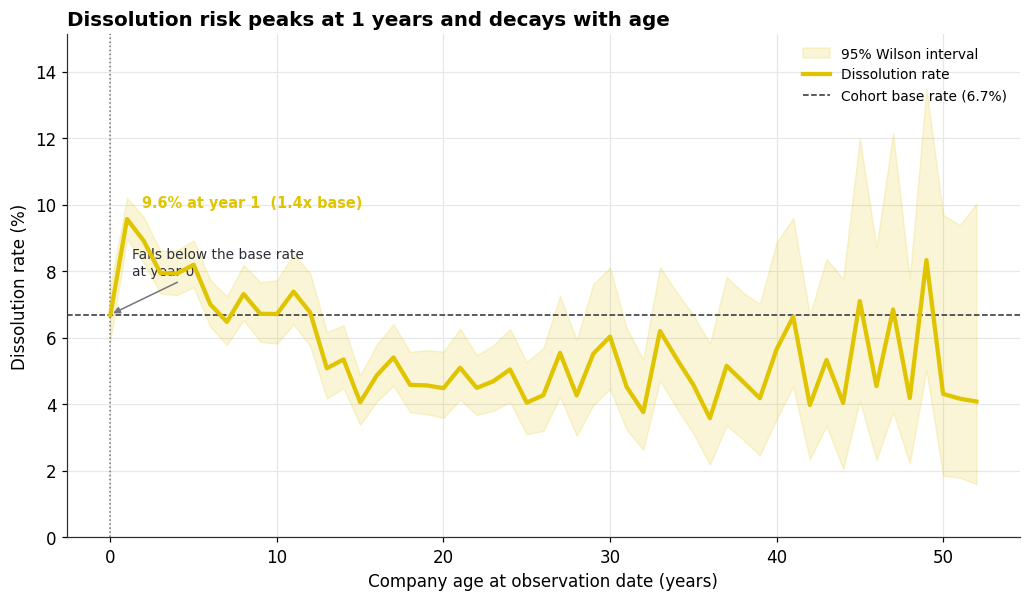

_ageband     n  dissolved     rate     lift
      <2 12158     1063.0 0.087432 1.305951
     2-5 19667     1626.0 0.082677 1.234918
    5-10 22208     1605.0 0.072271 1.079497
   10-20 22462     1234.0 0.054937 0.820583
     20+ 22431     1095.0 0.048816 0.729157


In [31]:
if "company_age_years" in train_df.columns:
    ac = train_df[["company_age_years", "label"]].dropna().copy()
    ac["_yr"] = np.floor(ac["company_age_years"].clip(lower=0)).astype(int)
    g = (ac.groupby("_yr").agg(n=("label", "size"), dissolved=("label", "sum"))
         .reset_index())
    g = g[g["n"] >= 50]
    g = g[g["_yr"] <= int(np.ceil(ac["company_age_years"].quantile(0.99)))]

    if len(g) < 5:
        print("Too few age years with adequate support; curve skipped.")
    else:
        z = 1.96
        p_hat = g["dissolved"]/g["n"]
        den = 1 + z**2/g["n"]
        centre = (p_hat + z**2/(2*g["n"]))/den
        half = z*np.sqrt(p_hat*(1-p_hat)/g["n"] + z**2/(4*g["n"]**2))/den
        g["rate"], g["lo"], g["hi"] = p_hat, (centre-half).clip(lower=0), (centre+half)
        g["lift"] = g["rate"]/base_rate
        g.to_csv(TABLES_DIR / "age_curve_dissolution_rates.csv", index=False)

        fig, ax = plt.subplots(figsize=(9.5, 5.6))
        ax.fill_between(g["_yr"], g["lo"]*100, g["hi"]*100, color=RISK, alpha=0.16,
                        zorder=2, label="95% Wilson interval")
        ax.plot(g["_yr"], g["rate"]*100, color=RISK, linewidth=2.8, zorder=4,
                label="Dissolution rate")
        ax.axhline(base_rate*100, color=REFLINE, linestyle="--", linewidth=1.0, zorder=3,
                   label=f"Cohort base rate ({base_rate:.1%})")
        cross = g[g["rate"] <= base_rate]
        if len(cross):
            xc = int(cross["_yr"].iloc[0])
            ax.axvline(xc, color=GREY, linestyle=":", linewidth=1.0, zorder=3)
            ax.annotate(f"Falls below the base rate\nat year {xc}", xy=(xc, base_rate*100),
                        xytext=(14, 26), textcoords="offset points", fontsize=9,
                        color=REFLINE,
                        arrowprops=dict(arrowstyle="-|>", color=GREY, lw=1.0))
        pk = g.loc[g["rate"].idxmax()]
        ax.annotate(f"{pk['rate']:.1%} at year {int(pk['_yr'])}  ({pk['lift']:.1f}x base)",
                    xy=(pk["_yr"], pk["rate"]*100), xytext=(10, 8),
                    textcoords="offset points", fontsize=9.5, fontweight="bold",
                    color=RISK)
        ax.set_xlabel("Company age at observation date (years)")
        ax.set_ylabel("Dissolution rate (%)")
        ax.set_title(f"Dissolution risk peaks at {int(pk['_yr'])} years and decays with age",
                     loc="left")
        ax.set_ylim(0, float(g["hi"].max()*100)*1.12)
        ax.legend(loc="upper right", fontsize=9)
        add_source(fig, SRC + "  One point per year of company age, years with fewer than 50 "
                              "companies suppressed, x-axis truncated at the 99th percentile "
                              "of age. Band is the Wilson score interval, so its width shows "
                              "where the estimate is thin. The banded version of the same data "
                              "is in age_band_dissolution_rates.csv.")
        plt.tight_layout()
        save_fig(fig, "fig_06_age_curve")
        plt.show()

    train_df["_ageband"] = pd.cut(train_df["company_age_years"].clip(lower=0),
                                  bins=[0, 2, 5, 10, 20, np.inf],
                                  labels=["<2", "2-5", "5-10", "10-20", "20+"], right=False)
    ab = (train_df.groupby("_ageband", observed=True)
          .agg(n=("label", "count"), dissolved=("label", "sum")).reset_index())
    ab["rate"] = ab["dissolved"]/ab["n"]
    ab["lift"] = ab["rate"]/base_rate
    ab.to_csv(TABLES_DIR / "age_band_dissolution_rates.csv", index=False)
    print(ab.to_string(index=False))
else:
    print("company_age_years absent; skipped.")


### Figure 2.9 - Dissolution rate by county (Spatial)

Ranked bar always; choropleth additionally if `geopandas` and a boundary file are available.

County mapping: 98,437 of 98,926 resolved to a named county (99.5%); 489 missing or placeholder (excluded, not plotted as a category).
Suppressed 2 county/counties with fewer than 30 companies.
  saved: fig_07_county_risk


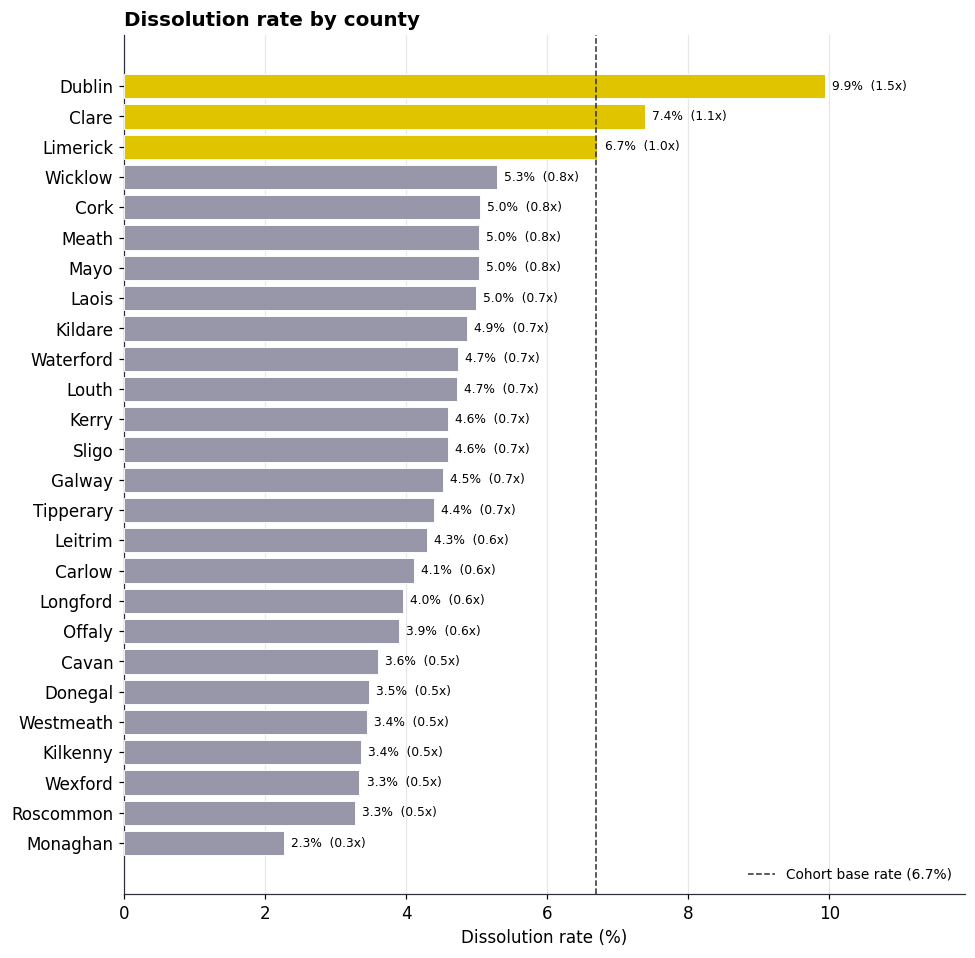

In [32]:
county_col = next((c for c in ["county", "county_name", "registered_county",
                                "reg_county", "addr_county"] if c in train_df.columns), None)

NOT_A_COUNTY = {"", "unknown", "unspecified", "none", "null", "n/a", "na", "nan",
                "not stated", "not specified", "other", "-"}

def clean_county(v):
    if pd.isna(v):
        return None
    s = str(v).strip()
    return None if s.lower() in NOT_A_COUNTY else s.title()

if county_col:
    train_df["_county"] = train_df[county_col].apply(clean_county)
    n_ok = train_df["_county"].notna().sum()
    print(f"County mapping: {n_ok:,} of {len(train_df):,} resolved to a named county "
          f"({n_ok/len(train_df):.1%}); {len(train_df)-n_ok:,} missing or placeholder "
          f"(excluded, not plotted as a category).")

    MIN_N = 30
    ct = (train_df.dropna(subset=["_county"])
          .groupby("_county").agg(n=("label", "count"), dissolved=("label", "sum"))
          .reset_index())
    ct["rate"] = ct["dissolved"]/ct["n"]
    ct["lift"] = ct["rate"]/base_rate
    small = ct[ct["n"] < MIN_N]
    if len(small):
        print(f"Suppressed {len(small)} county/counties with fewer than {MIN_N} companies.")
    ct = ct[ct["n"] >= MIN_N].sort_values("rate")
    ct.to_csv(TABLES_DIR / "county_dissolution_rates.csv", index=False)

    if len(ct):
        cols = [RISK if r > base_rate else SAFE for r in ct["rate"]]
        fig, ax = plt.subplots(figsize=(9, max(5, 0.34*len(ct))))
        ax.barh(ct["_county"], ct["rate"]*100, color=cols, edgecolor="white",
                linewidth=0.6, zorder=3)
        ax.axvline(base_rate*100, color=REFLINE, linestyle="--", linewidth=1.0, zorder=4,
                   label=f"Cohort base rate ({base_rate:.1%})")
        ax.set_xlabel("Dissolution rate (%)")
        ax.set_title("Dissolution rate by county", loc="left")
        ax.grid(axis="y", visible=False)
        for i, (_, r) in enumerate(ct.iterrows()):
            ax.text(r["rate"]*100+0.1, i, f"{r['rate']*100:.1f}%  ({r['lift']:.1f}x)",
                    va="center", fontsize=8)
        ax.margins(x=0.2)
        ax.legend(loc="lower right", fontsize=9)
        add_source(fig, SRC + f"  Counties with at least {MIN_N} companies. Companies without a "
                        f"resolved county are excluded rather than shown as a category.")
        plt.tight_layout()
        save_fig(fig, "fig_07_county_risk")
        plt.show()
    else:
        print("No county met the minimum size; figure skipped.")

else:
    print("No county name column found; county figures skipped.")

### Figure 2.10 - Feature correlation structure (Correlation, appendix)

  saved: fig_08_correlation


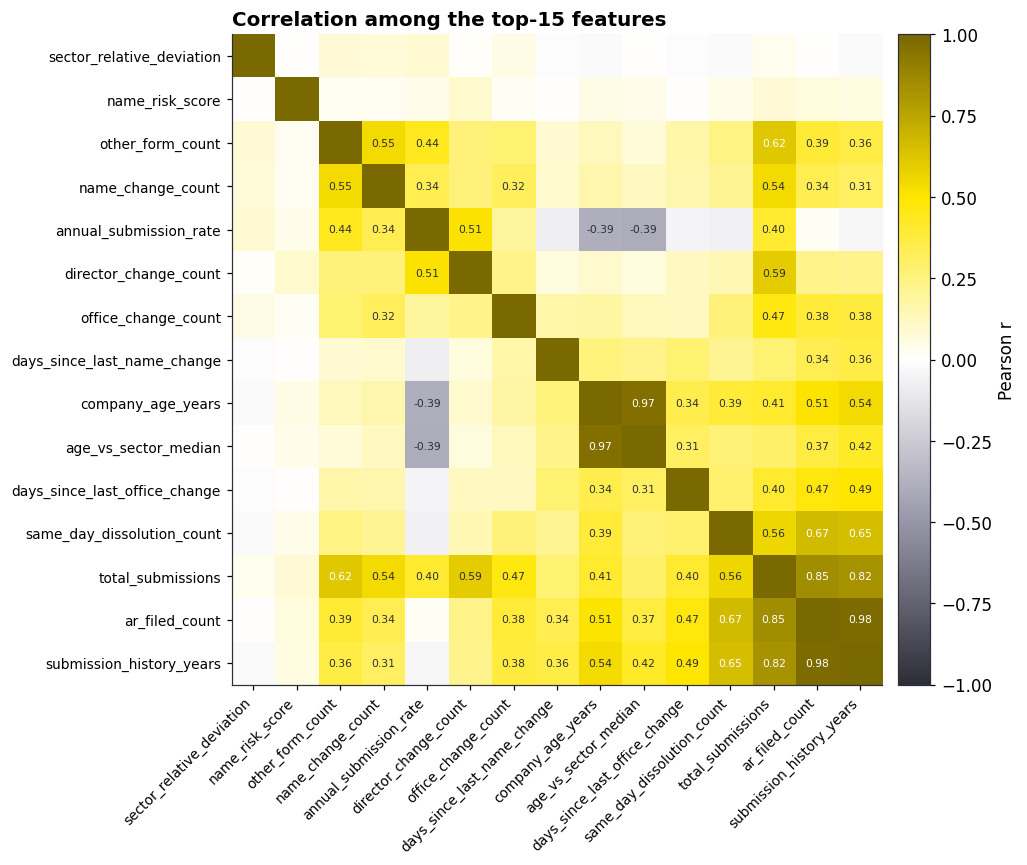

High-correlation pairs across all 84 features (|r|>0.70): 23


In [33]:
corr_feats = [f for f in TOP15 if f in train_df.columns]
corr = train_df[corr_feats].select_dtypes(include=[np.number]).corr()
try:
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import squareform
    order = leaves_list(linkage(squareform((1-corr.abs()).values, checks=False), method="average"))
    corr = corr.iloc[order, order]
except Exception as e:
    print(f"Clustering skipped ({e}).")

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr.values, cmap=EY_DIV, vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02).set_label("Pearson r")
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        if i != j and abs(v) >= 0.3:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.6 else CHARCOAL)
ax.set_title("Correlation among the top-15 features", loc="left")
ax.grid(False)
add_source(fig, SRC + "  Hierarchically clustered. Values shown where |r| >= 0.30. "
                "All 84 features and every pair with |r| > 0.70 are in correlation_high_pairs.csv.")
plt.tight_layout()
save_fig(fig, "fig_08_correlation")
plt.show()

num_all = train_df[feat_cols].select_dtypes(include=[np.number])
corr_all = num_all.corr()
pairs = [(corr_all.columns[i], corr_all.columns[j], round(corr_all.iloc[i, j], 3))
         for i in range(len(corr_all)) for j in range(i+1, len(corr_all))
         if abs(corr_all.iloc[i, j]) > 0.7]
pd.DataFrame(pairs, columns=["feature_a", "feature_b", "r"]).sort_values(
    "r", key=lambda s: s.abs(), ascending=False).to_csv(
    TABLES_DIR / "correlation_high_pairs.csv", index=False)
print(f"High-correlation pairs across all {len(feat_cols)} features (|r|>0.70): {len(pairs)}")

### Figure 2.11 - Distribution diagnostics (Distribution, appendix)

  saved: fig_09_distribution_diagnostics


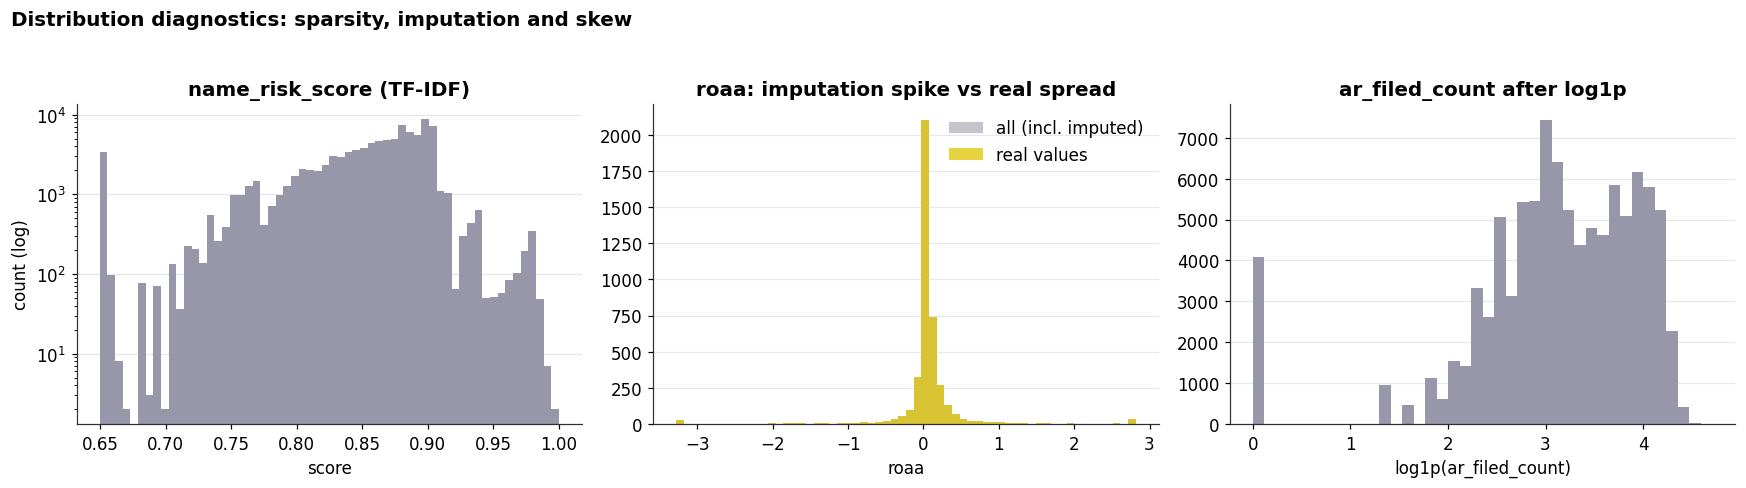

Distribution summary saved.


In [34]:
from scipy import stats as _stats
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Distribution diagnostics: sparsity, imputation and skew",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
if "name_risk_score" in train_df.columns:
    axes[0].hist(train_df["name_risk_score"].dropna(), bins=60, color=SAFE)
    axes[0].set_yscale("log"); axes[0].set_title("name_risk_score (TF-IDF)")
    axes[0].set_xlabel("score"); axes[0].set_ylabel("count (log)")
if "roaa" in train_df.columns:
    real = train_df.loc[train_df.get("roaa_present", 1) == 1, "roaa"].dropna()
    axes[1].hist(train_df["roaa"].dropna(), bins=60, color=LIGHT, label="all (incl. imputed)")
    if len(real):
        axes[1].hist(real, bins=60, color=RISK, alpha=0.75, label="real values")
    axes[1].set_title("roaa: imputation spike vs real spread")
    axes[1].set_xlabel("roaa"); axes[1].legend()
if "ar_filed_count" in train_df.columns:
    axes[2].hist(np.log1p(train_df["ar_filed_count"].clip(lower=0)), bins=40, color=SAFE)
    axes[2].set_title("ar_filed_count after log1p"); axes[2].set_xlabel("log1p(ar_filed_count)")
for ax in axes:
    ax.grid(axis="x", visible=False)
add_source(fig, SRC)
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_fig(fig, "fig_09_distribution_diagnostics")
plt.show()

rows = []
for c in ["ar_filed_count", "total_submissions", "director_change_count",
          "same_day_reg_count", "roaa", "ebit_margin"]:
    if c in train_df.columns:
        s = train_df[c].dropna()
        rows.append({"feature": c, "mean": round(s.mean(), 3), "median": round(s.median(), 3),
                     "skew": round(float(_stats.skew(s)), 2) if len(s) > 2 else None})
pd.DataFrame(rows).to_csv(TABLES_DIR / "distribution_summary.csv", index=False)
print("Distribution summary saved.")

## Section 5 - Results (Chapter 5)

Each cell tries the artefact CSV first and falls back to the locked verified value, printing which source it used.

### Figure 5.1 - Model comparison, average precision (Ranking)

Model performance source: model_comparison.csv
Columns used -> model=model, ap=avg_precision, auc=auc_roc, CIs=yes
  saved: fig_10_model_ap


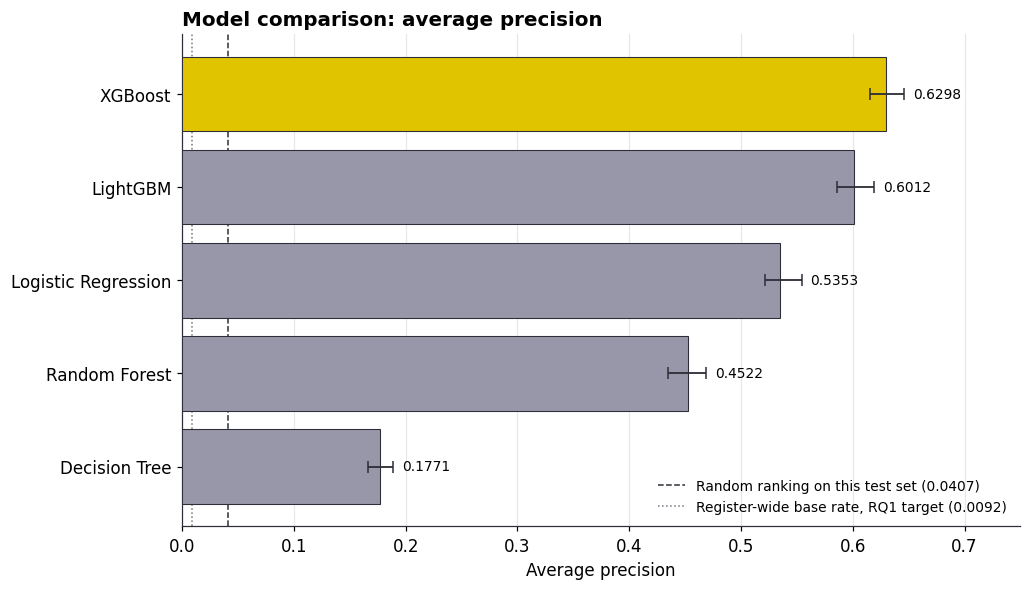

In [35]:
NAIVE_AP_REGISTER = 0.0092

mc = try_read("model_comparison.csv")
mcol = pick_col(mc, "model", "model_name", "estimator", "classifier")
apc  = pick_col(mc, "avg_precision", "average_precision", "ap", "pr_auc")
aucc = pick_col(mc, "auc_roc", "roc_auc", "auc", "auroc")
ap_lo = pick_col(mc, "ap_ci_lo"); ap_hi = pick_col(mc, "ap_ci_hi")
au_lo = pick_col(mc, "auc_ci_lo"); au_hi = pick_col(mc, "auc_ci_hi")

if mc is not None and mcol and apc:
    perf = pd.DataFrame({"model": mc[mcol].astype(str), "ap": mc[apc].astype(float)})
    if aucc: perf["auc"] = mc[aucc].astype(float)
    for tgt, sc in [("ap_lo", ap_lo), ("ap_hi", ap_hi), ("auc_lo", au_lo), ("auc_hi", au_hi),
                    ("ks", pick_col(mc, "ks_stat", "ks")),
                    ("brier", pick_col(mc, "brier_score", "brier"))]:
        if sc: perf[tgt] = mc[sc].astype(float)
    used = "model_comparison.csv"
else:
    raise FileNotFoundError(
        "model_comparison.csv not found, or its model/avg_precision columns could not be "
        "identified. Run 04_model_training.ipynb. This figure is not drawn from a stored "
        "constant.")
used = "model_comparison.csv"
print(f"Model performance source: {used}")
print(f"Columns used -> model={mcol}, ap={apc}, auc={aucc}, CIs={'yes' if ap_lo else 'no'}")

perf = perf.sort_values("ap").reset_index(drop=True)
perf.to_csv(TABLES_DIR / "model_performance_figure_data.csv", index=False)

has_ci = {"ap_lo", "ap_hi"}.issubset(perf.columns)
fig, ax = plt.subplots(figsize=(9.5, 5.5))
cols = [RISK if m.lower().startswith("xgb") else MID for m in perf["model"]]
ax.barh(perf["model"], perf["ap"], color=cols, edgecolor=CHARCOAL, linewidth=0.7, zorder=3)
if has_ci:
    ax.errorbar(perf["ap"], range(len(perf)),
                xerr=[perf["ap"]-perf["ap_lo"], perf["ap_hi"]-perf["ap"]],
                fmt="none", ecolor=REFLINE, capsize=4, linewidth=1.2, zorder=4)
ax.axvline(test_rate, color=REFLINE, linestyle="--", linewidth=1.0, zorder=2,
           label=f"Random ranking on this test set ({test_rate:.4f})")
ax.axvline(NAIVE_AP_REGISTER, color=GREY, linestyle=":", linewidth=1.0, zorder=2,
           label=f"Register-wide base rate, RQ1 target ({NAIVE_AP_REGISTER:.4f})")
ax.set_xlabel("Average precision")
ax.set_title("Model comparison: average precision", loc="left")
ax.grid(axis="y", visible=False)
for i, (_, r) in enumerate(perf.iterrows()):
    ax.text((r["ap_hi"] if has_ci else r["ap"]) + 0.008, i, f"{r['ap']:.4f}",
            va="center", fontsize=9)
ax.legend(loc="lower right", fontsize=9)
ax.margins(x=0.16)
add_source(fig, f"Source: {used}. Held-out test partition (n={n_test:,}). "
                + ("Error bars are the bootstrap 95% CI for each model. " if has_ci else "")
                + f"Two baselines are drawn because the chapter reports both: average "
                  f"precision on this partition is measured against its own {test_rate:.2%} "
                  f"positive rate, while the RQ1 target of {NAIVE_AP_REGISTER:.4f} is the "
                  f"register-wide rate before the cold-start exclusion.")
plt.tight_layout()
save_fig(fig, "fig_10_model_ap")
plt.show()

### Figure 5.2 - Model comparison, AUC (Ranking)

AUC alongside AP because the classes are heavily imbalanced. The AP rank against each bar is the point: the AUC leader is not the AP leader, which is why AP is the selection metric.

  saved: fig_11_model_auc


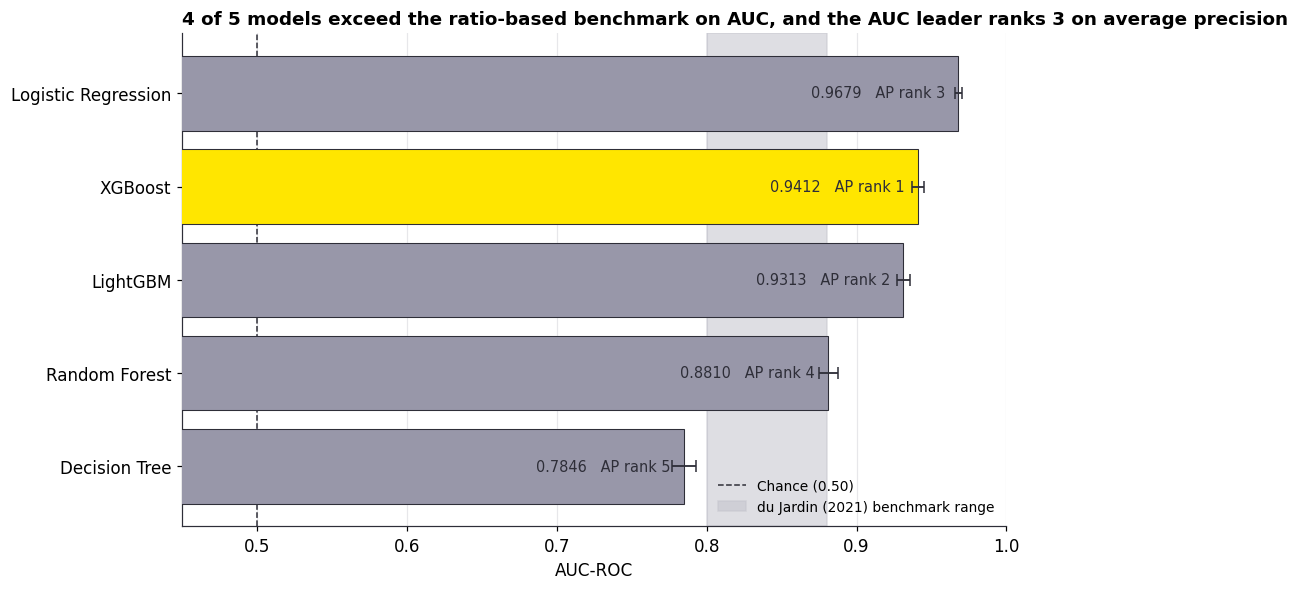

In [36]:
if "auc" in perf.columns:
    pa = perf.sort_values("auc").reset_index(drop=True)
    ap_rank = {m: r for r, m in enumerate(
        perf.sort_values("ap", ascending=False)["model"], start=1)}
    has_auc_ci = {"auc_lo", "auc_hi"}.issubset(pa.columns)

    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    cols = [ACCENT if str(m).lower().startswith("xgb") else MID for m in pa["model"]]
    ax.barh(pa["model"], pa["auc"], color=cols, edgecolor=CHARCOAL, linewidth=0.7, zorder=3)
    if has_auc_ci:
        ax.errorbar(pa["auc"], range(len(pa)),
                    xerr=[pa["auc"]-pa["auc_lo"], pa["auc_hi"]-pa["auc"]],
                    fmt="none", ecolor=REFLINE, capsize=4, linewidth=1.2, zorder=4)
    ax.axvline(0.5, color=REFLINE, linestyle="--", linewidth=1.0, zorder=2, label="Chance (0.50)")
    ax.axvspan(0.80, 0.88, color=LIGHT, alpha=0.55, zorder=1,
               label="du Jardin (2021) benchmark range")
    for i, (_, r) in enumerate(pa.iterrows()):
        ax.text(r["auc"] - 0.009, i, f"{r['auc']:.4f}   AP rank {ap_rank[r['model']]}",
                va="center", ha="right", fontsize=9.5, color=CHARCOAL, zorder=5)
    ax.set_xlabel("AUC-ROC")
    ax.set_xlim(0.45, 1.0)
    _n_over = int((pa["auc"] > 0.88).sum())
    _auc_leader = pa.loc[pa["auc"].idxmax(), "model"]
    ax.set_title(f"{_n_over} of {len(pa)} models exceed the ratio-based benchmark on AUC, and "
                 f"the AUC leader ranks {ap_rank[_auc_leader]} on average precision",
                 loc="left", fontsize=12)
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower right", fontsize=9)
    add_source(fig, f"Source: {used}. Held-out test partition (n={n_test:,}). "
                    + ("Error bars are the bootstrap 95% CI. " if has_auc_ci else "")
                    + f"AUC is inflated by the {1-test_rate:.0%} negative majority, so "
                      f"average precision is the selection metric; the AP rank against each bar "
                      f"is why. Benchmark range from du Jardin (2021).")
    plt.tight_layout()
    save_fig(fig, "fig_11_model_auc")
    plt.show()
else:
    print("AUC unavailable; figure skipped.")


Test partition n=94,421 | positives=3,841 (4.07%) | XGBoost: AP 0.6298  AUC 0.9412
  saved: fig_12_pr_curve


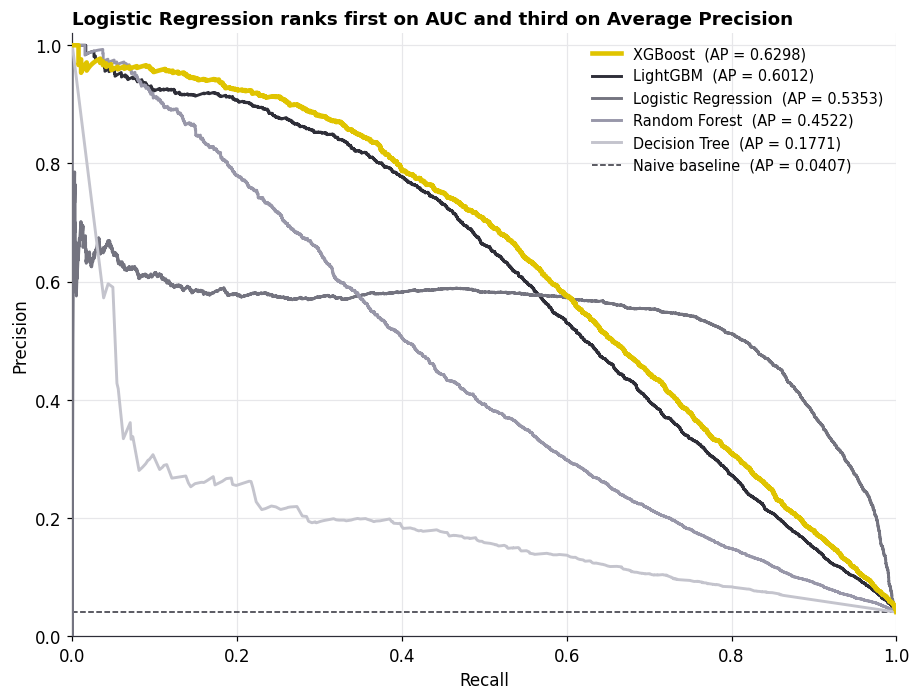

  saved: fig_13_roc_curve


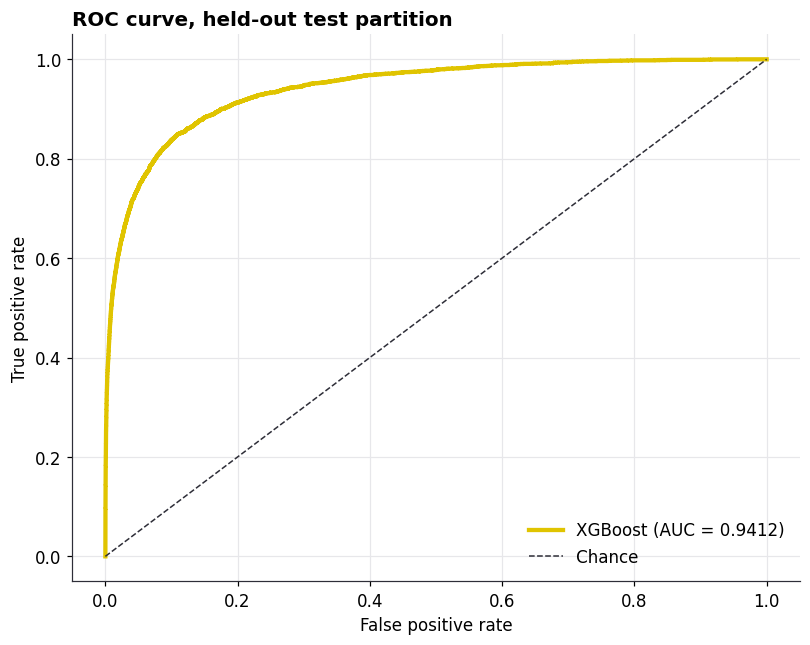

  saved: fig_14_calibration


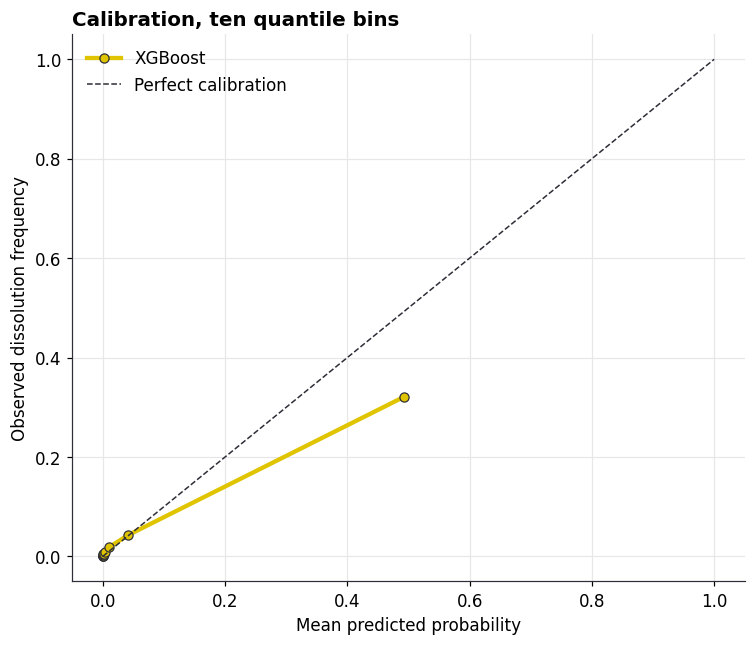

  saved: fig_15_ks_separation


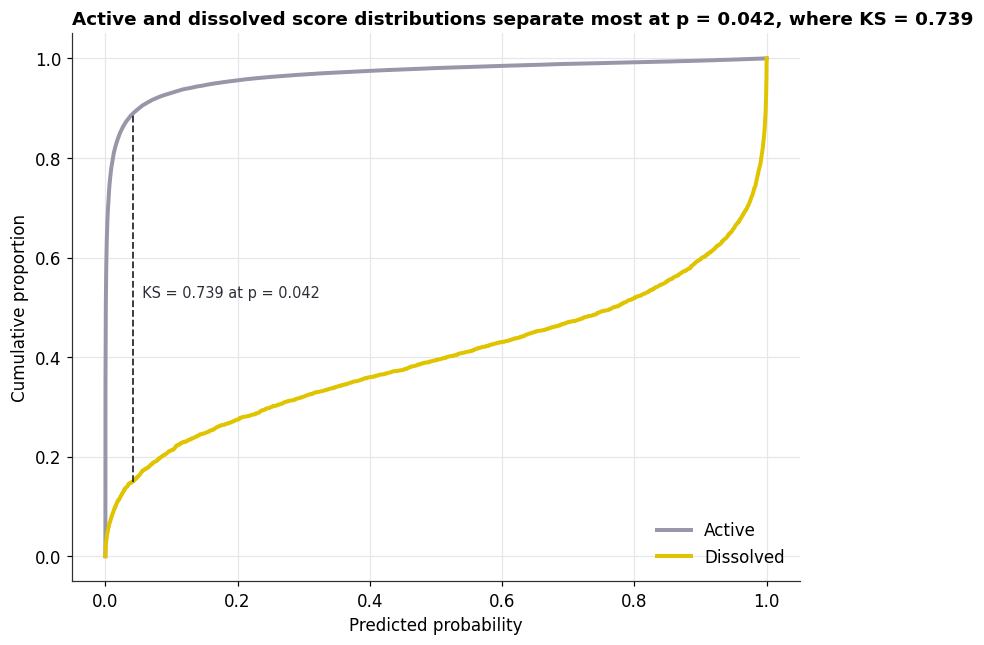

In [37]:
train_df = pd.read_csv(PROCESSED_FILES["train_set"], low_memory=False)
test_df = pd.read_csv(PROCESSED_FILES["test_set"], low_memory=False)

X_train = train_df[FEATURE_COLS].values
X_test = test_df[FEATURE_COLS].values
y = test_df["label"].values.astype(int)

from sklearn.impute import SimpleImputer
from sklearn.metrics import (precision_recall_curve, roc_curve,
                             average_precision_score, roc_auc_score)
from sklearn.calibration import calibration_curve

_imp = SimpleImputer(strategy="median").fit(X_train)
X_test_i = _imp.transform(X_test)

MODEL_INPUT = {"Logistic Regression": X_test, "Decision Tree": X_test_i,
               "Random Forest": X_test_i, "XGBoost": X_test, "LightGBM": X_test}

scores = {}
for _name, _Xin in MODEL_INPUT.items():
    _m = joblib.load(MODELS_DIR / (_name.lower().replace(" ", "_") + "_model.joblib"))
    scores[_name] = _m.predict_proba(_Xin)[:, 1]

_recomputed = {n: average_precision_score(y, s) for n, s in scores.items()}
_table = dict(zip(perf["model"], perf["ap"]))
_drift = {n: abs(_recomputed[n] - _table[n]) for n in _recomputed if n in _table}
if max(_drift.values()) > 0.01:
    raise ValueError(
        "Recomputed Average Precision does not reproduce model_comparison.csv:\n"
        + "\n".join(f"  {n:<22} recomputed {_recomputed[n]:.4f}  table {_table[n]:.4f}"
                     for n in sorted(_drift, key=_drift.get, reverse=True))
        + "\nThe saved models and the stored table disagree. Do not use these figures.")

winner_name = perf.sort_values("ap", ascending=False)["model"].iloc[0]
p = scores[winner_name]
preds = pd.DataFrame({"_p": p, "_y": y})
ap = average_precision_score(y, p)
auc_v = roc_auc_score(y, p)
print(f"Test partition n={len(y):,} | positives={y.sum():,} ({y.mean():.2%}) | "
      f"{winner_name}: AP {ap:.4f}  AUC {auc_v:.4f}")

_ORDINAL = {1: "first", 2: "second", 3: "third", 4: "fourth", 5: "fifth"}
_by_ap = list(perf.sort_values("ap", ascending=False)["model"])
_by_auc = list(perf.sort_values("auc", ascending=False)["model"])
_split = max(_by_auc, key=lambda m: _by_ap.index(m) - _by_auc.index(m))
_shades = [CHARCOAL, GREY, MID, LIGHT]

fig, ax = plt.subplots(figsize=(8.5, 6.5))
_si = 0
for _name in _by_ap:
    _pr, _rc, _ = precision_recall_curve(y, scores[_name])
    if _name == winner_name:
        ax.plot(_rc, _pr, color=RISK, linewidth=3.0, zorder=5,
                label=f"{_name}  (AP = {_recomputed[_name]:.4f})")
    else:
        ax.plot(_rc, _pr, color=_shades[_si], linewidth=1.9, zorder=3,
                label=f"{_name}  (AP = {_recomputed[_name]:.4f})")
        _si += 1
ax.axhline(y.mean(), color=REFLINE, linestyle="--", linewidth=1.0, zorder=2,
           label=f"Naive baseline  (AP = {y.mean():.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.02)
ax.set_xlim(0, 1.0)
ax.set_title(f"{_split} ranks {_ORDINAL[_by_auc.index(_split)+1]} on AUC and "
             f"{_ORDINAL[_by_ap.index(_split)+1]} on Average Precision",
             loc="left", fontsize=12)
ax.legend(loc="upper right", fontsize=9.5)
add_source(fig, f"Held-out test partition (n={len(y):,}, {y.mean():.2%} positive). Each "
                f"curve is the model saved in 04_model_training scored on the same "
                f"partition; the Average Precision in each label is the area under that "
                f"curve and matches Table 5.1. The baseline is the precision a classifier "
                f"achieves by ranking at random.")
plt.tight_layout()
save_fig(fig, "fig_12_pr_curve")
plt.show()

fpr, tpr, _ = roc_curve(y, p)
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(fpr, tpr, color=RISK, linewidth=2.8, label=f"{winner_name} (AUC = {auc_v:.4f})")
ax.plot([0, 1], [0, 1], color=REFLINE, linestyle="--", linewidth=1.0, label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve, held-out test partition", loc="left")
ax.legend(loc="lower right")
add_source(fig, f"Held-out test partition (n={len(y):,}). AUC {auc_v:.4f} against the 0.80 "
                f"to 0.88 range du Jardin (2021) reports for ratio-based ensembles.")
plt.tight_layout()
save_fig(fig, "fig_13_roc_curve")
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
pt, pp_ = calibration_curve(y, p, n_bins=10, strategy="quantile")
ax.plot(pp_, pt, "o-", color=RISK, linewidth=2.8, markeredgecolor=CHARCOAL,
        markeredgewidth=0.8, label=winner_name)
ax.plot([0, 1], [0, 1], color=REFLINE, linestyle="--", linewidth=1.0,
        label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed dissolution frequency")
ax.set_title("Calibration, ten quantile bins", loc="left")
ax.legend(loc="upper left")
add_source(fig, f"Held-out test partition (n={len(y):,}), raw classifier output. This is the "
                f"reliability before the isotonic calibration described in Section 4.7, and "
                f"is the position the Brier score in Table 5.1 measures.")
plt.tight_layout()
save_fig(fig, "fig_14_calibration")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 6))
for lab, col, nm in [(0, MID, "Active"), (1, RISK, "Dissolved")]:
    v = np.sort(p[y == lab])
    ax.plot(v, np.arange(1, len(v)+1)/max(len(v), 1), color=col, linewidth=2.6, label=nm)
g = np.linspace(0, 1, 500)
c0 = np.searchsorted(np.sort(p[y == 0]), g)/max((y == 0).sum(), 1)
c1 = np.searchsorted(np.sort(p[y == 1]), g)/max((y == 1).sum(), 1)
k = int(np.argmax(np.abs(c0-c1)))
ks = abs(c0[k]-c1[k])
ax.vlines(g[k], c1[k], c0[k], color=REFLINE, linestyle="--", linewidth=1.2)
ax.text(g[k], (c0[k]+c1[k])/2, f"  KS = {ks:.3f} at p = {g[k]:.3f}", fontsize=9.5,
        color=REFLINE)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Cumulative proportion")
ax.set_title(f"Active and dissolved score distributions separate most at p = {g[k]:.3f}, "
             f"where KS = {ks:.3f}", loc="left", fontsize=12)
ax.legend(loc="lower right")
add_source(fig, f"Held-out test partition (n={len(y):,}). The dashed line marks the point of "
                f"maximum separation between the two cumulative distributions.")
plt.tight_layout()
save_fig(fig, "fig_15_ks_separation")
plt.show()

### Figure 5.9 - Portfolio triage yield (Distribution)

What share of the companies that dissolve is recovered by reviewing what share of the portfolio, against reviewing in no particular order. This is the figure Chapter 6 needs for the analyst-hours argument.

  saved: fig_23_triage_gains


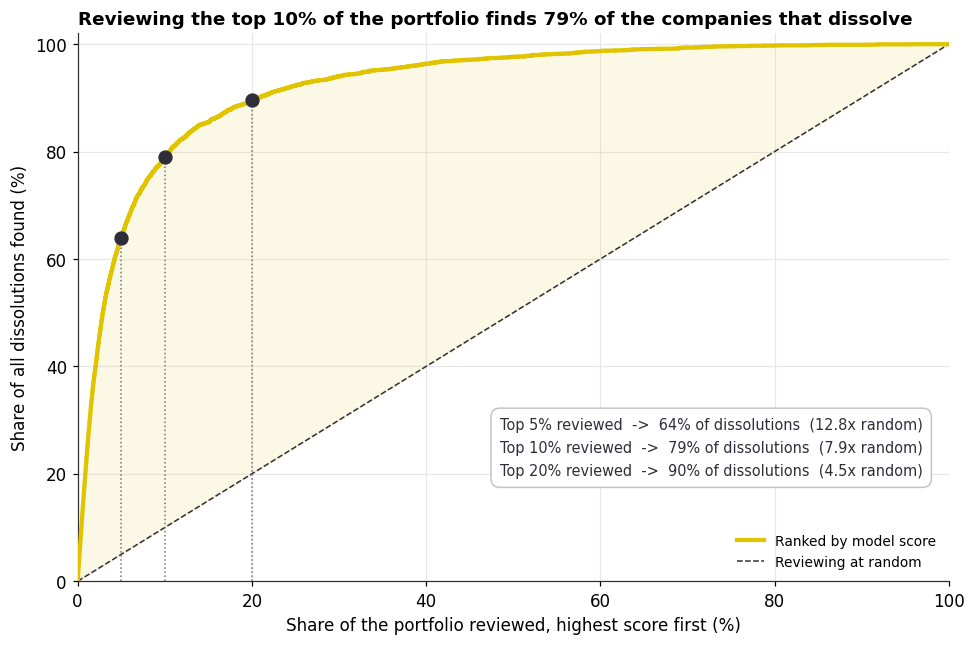

 portfolio_share  dissolutions_captured  lift_over_random
            0.05               0.639938         12.798750
            0.10               0.789898          7.898985
            0.20               0.895600          4.478001


In [38]:
_y = preds["_y"].values
_p = preds["_p"].values
order = np.argsort(-_p)
y_s = _y[order]
n_tot = len(y_s)
pos_tot = int(y_s.sum())
x_share = np.arange(1, n_tot+1)/n_tot
y_share = np.cumsum(y_s)/max(pos_tot, 1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x_share*100, y_share*100, color=RISK, linewidth=2.8, zorder=4,
        label="Ranked by model score")
ax.plot([0, 100], [0, 100], color=REFLINE, linestyle="--", linewidth=1.0, zorder=3,
        label="Reviewing at random")
ax.fill_between(x_share*100, x_share*100, y_share*100, color=RISK, alpha=0.10, zorder=2)

marks = []
lines = []
for q in (0.05, 0.10, 0.20):
    idx = max(int(np.floor(q*n_tot)) - 1, 0)
    cap = float(y_share[idx])
    marks.append({"portfolio_share": q, "dissolutions_captured": cap,
                  "lift_over_random": cap/q})
    ax.plot([q*100, q*100], [0, cap*100], color=GREY, linestyle=":", linewidth=1.0,
            zorder=3)
    ax.scatter([q*100], [cap*100], s=70, color=REFLINE, zorder=5)
    lines.append(f"Top {q:.0%} reviewed  ->  {cap:.0%} of dissolutions  ({cap/q:.1f}x random)")
ax.text(0.97, 0.30, "\n".join(lines), transform=ax.transAxes, ha="right", va="top",
        fontsize=9.5, color=REFLINE, linespacing=1.7,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor=LIGHT))
ax.set_xlabel("Share of the portfolio reviewed, highest score first (%)")
ax.set_ylabel("Share of all dissolutions found (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 102)
top10 = marks[1]["dissolutions_captured"]
ax.set_title(f"Reviewing the top 10% of the portfolio finds {top10:.0%} of the "
             f"companies that dissolve", loc="left", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
add_source(fig, f"Held-out test partition (n={n_tot:,}, {pos_tot:,} dissolutions), ranked by "
                f"the Stage 1 score. The diagonal is the yield of reviewing the same share of "
                f"clients in no particular order, which is the manual triage this replaces. "
                f"Yield is measured on the test partition, not on a live portfolio.")
plt.tight_layout()
save_fig(fig, "fig_23_triage_gains")
plt.show()
pd.DataFrame(marks).to_csv(TABLES_DIR / "triage_gains.csv", index=False)
print(pd.DataFrame(marks).to_string(index=False))

### Figure 5.8 - SHAP global importance (Ranking)

Top-5 driver highlight taken from parsimony_top15.csv (SHAP ranking): ['ar_filed_count', 'company_age_years', 'annual_submission_rate', 'total_submissions', 'director_change_count']
Parsed top_drivers_json: 231,792 driver records from 28,974 companies (0 unparseable).
  saved: fig_16_shap_importance


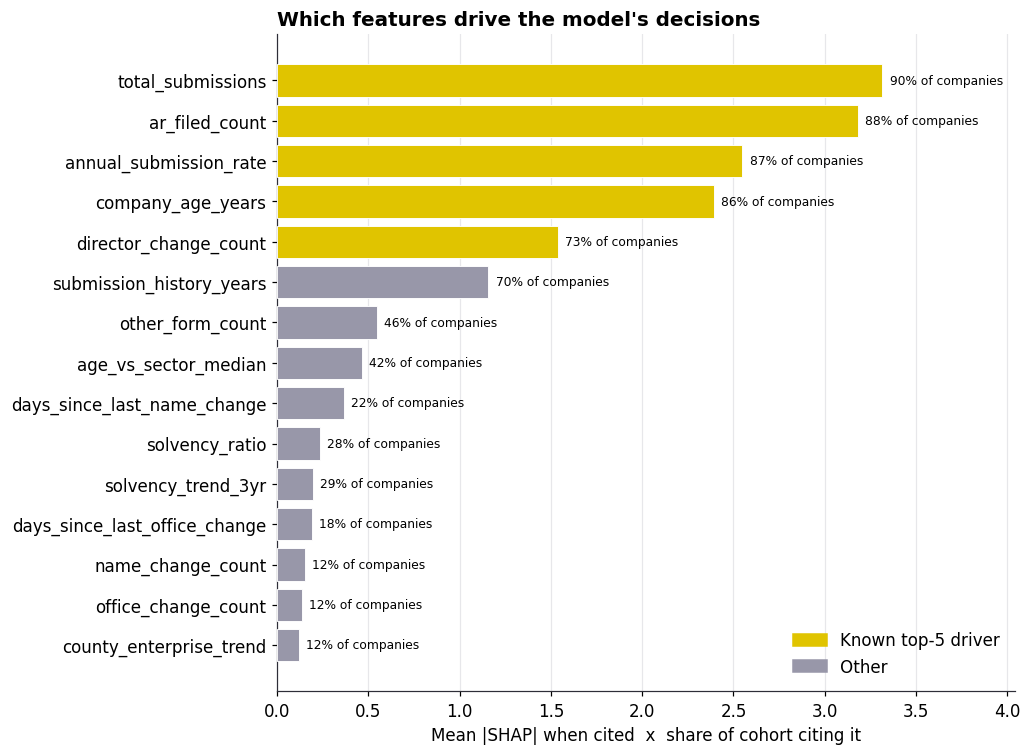

  saved: fig_17_shap_direction


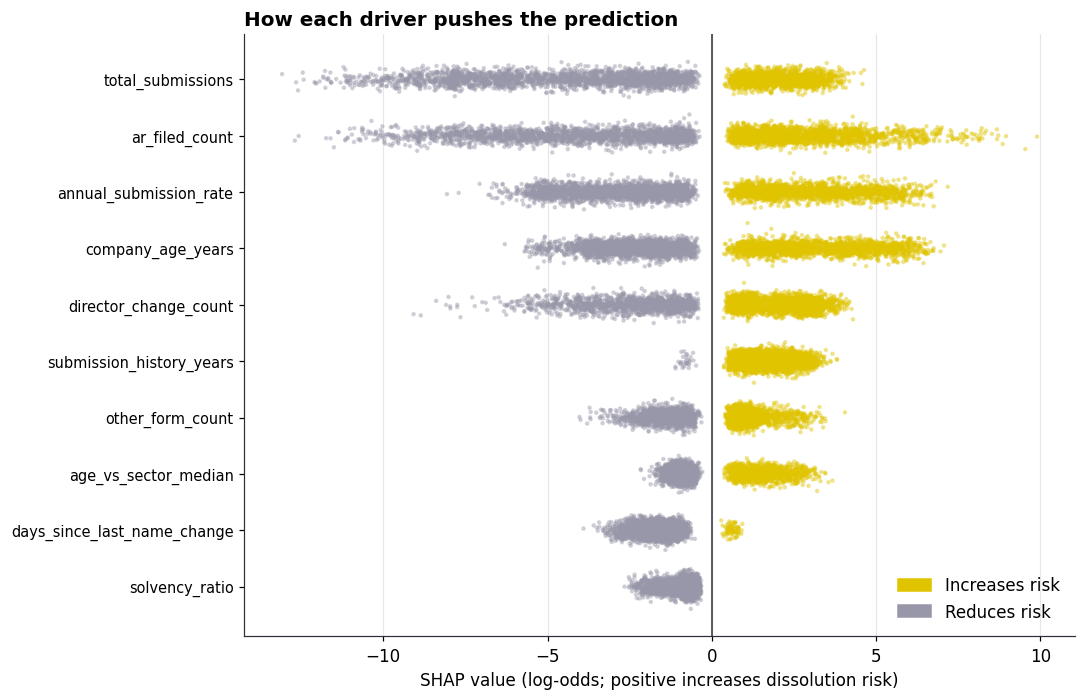

In [ ]:
TOP5_SHAP = TOP15[:5]
print(f"Top-5 driver highlight taken from {TOP15_SRC}: {TOP5_SHAP}")

import json as _json

sv = try_read("prospective_shap.csv")
drv = None
if sv is not None and "top_drivers_json" in sv.columns:
    recs, bad = [], 0
    ids = sv["company_num"] if "company_num" in sv.columns else pd.Series(range(len(sv)))
    for cid, js in zip(ids, sv["top_drivers_json"]):
        try:
            for d in _json.loads(js):
                recs.append({"company_num": cid, "feature": d["feature"], "shap": d["shap"]})
        except Exception:
            bad += 1
    drv = pd.DataFrame(recs)
    print(f"Parsed top_drivers_json: {len(drv):,} driver records from {len(sv):,} companies "
          f"({bad} unparseable).")

if drv is None or drv.empty:
    print("prospective_shap.csv not found or has no top_drivers_json column; SHAP figures skipped.")
else:
    drv["abs_shap"] = drv["shap"].abs()
    imp = (drv.groupby("feature")
           .agg(mean_abs_shap=("abs_shap", "mean"), companies=("company_num", "nunique"))
           .reset_index())
    imp["share_of_cohort"] = imp["companies"]/len(sv)
    imp["influence"] = imp["mean_abs_shap"]*imp["share_of_cohort"]
    imp = imp.sort_values("influence", ascending=False)
    imp.to_csv(TABLES_DIR / "shap_driver_importance.csv", index=False)

    top = imp.head(15).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9.5, 7))
    cols = [RISK if f in TOP5_SHAP else MID for f in top["feature"]]
    ax.barh(top["feature"], top["influence"], color=cols, edgecolor="white",
            linewidth=0.6, zorder=3)
    ax.set_xlabel("Mean |SHAP| when cited  x  share of cohort citing it")
    ax.set_title("Which drivers the narrative layer surfaces to a reader", loc="left")
    ax.grid(axis="y", visible=False)
    for i, (_, r) in enumerate(top.iterrows()):
        ax.text(r["influence"] + top["influence"].max()*0.012, i,
                f"{r['share_of_cohort']:.0%} of companies", va="center", fontsize=8)
    ax.legend(handles=[Patch(color=RISK, label="Known top-5 driver"),
                       Patch(color=MID, label="Other")], loc="lower right")
    ax.margins(x=0.22)
    add_source(fig, f"Source: prospective_shap.csv, top_drivers_json parsed for {len(sv):,} "
                    f"companies. Each company contributes only its own top drivers, so this "
                    f"ranks features by how often and how strongly they drive a decision, not "
                    f"by a mean over the whole cohort.")
    plt.tight_layout()
    save_fig(fig, "fig_16_shap_importance")
    plt.show()

    order = imp.head(10)["feature"].tolist()[::-1]
    fig, ax = plt.subplots(figsize=(10, 6.5))
    rng = np.random.default_rng(42)
    for i, f in enumerate(order):
        v = drv.loc[drv["feature"] == f, "shap"].values
        if len(v) > 4000:
            v = rng.choice(v, 4000, replace=False)
        ax.scatter(v, i + rng.normal(0, 0.09, len(v)),
                   s=4, c=np.where(v > 0, RISK, SAFE), alpha=0.35, zorder=3)
    ax.axvline(0, color=REFLINE, linewidth=1.0, zorder=4)
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=9.5)
    ax.set_xlabel("SHAP value (log-odds; positive increases dissolution risk)")
    ax.set_title("How each driver pushes the prediction", loc="left")
    ax.grid(axis="y", visible=False)
    ax.legend(handles=[Patch(color=RISK, label="Increases risk"),
                       Patch(color=SAFE, label="Reduces risk")], loc="lower right")
    add_source(fig, "Source: prospective_shap.csv, top_drivers_json. One point per company for "
                    "which the feature was a top driver.")
    plt.tight_layout()
    save_fig(fig, "fig_17_shap_direction")
    plt.show()

### Figure 5.12 - Filing behaviour versus financial ratios (Ranking)

The two-experiment financial ablation. Fifteen model-by-feature-set results at register scale, and ten on the Orbis-covered subset.

  saved: fig_19_financial_ablation


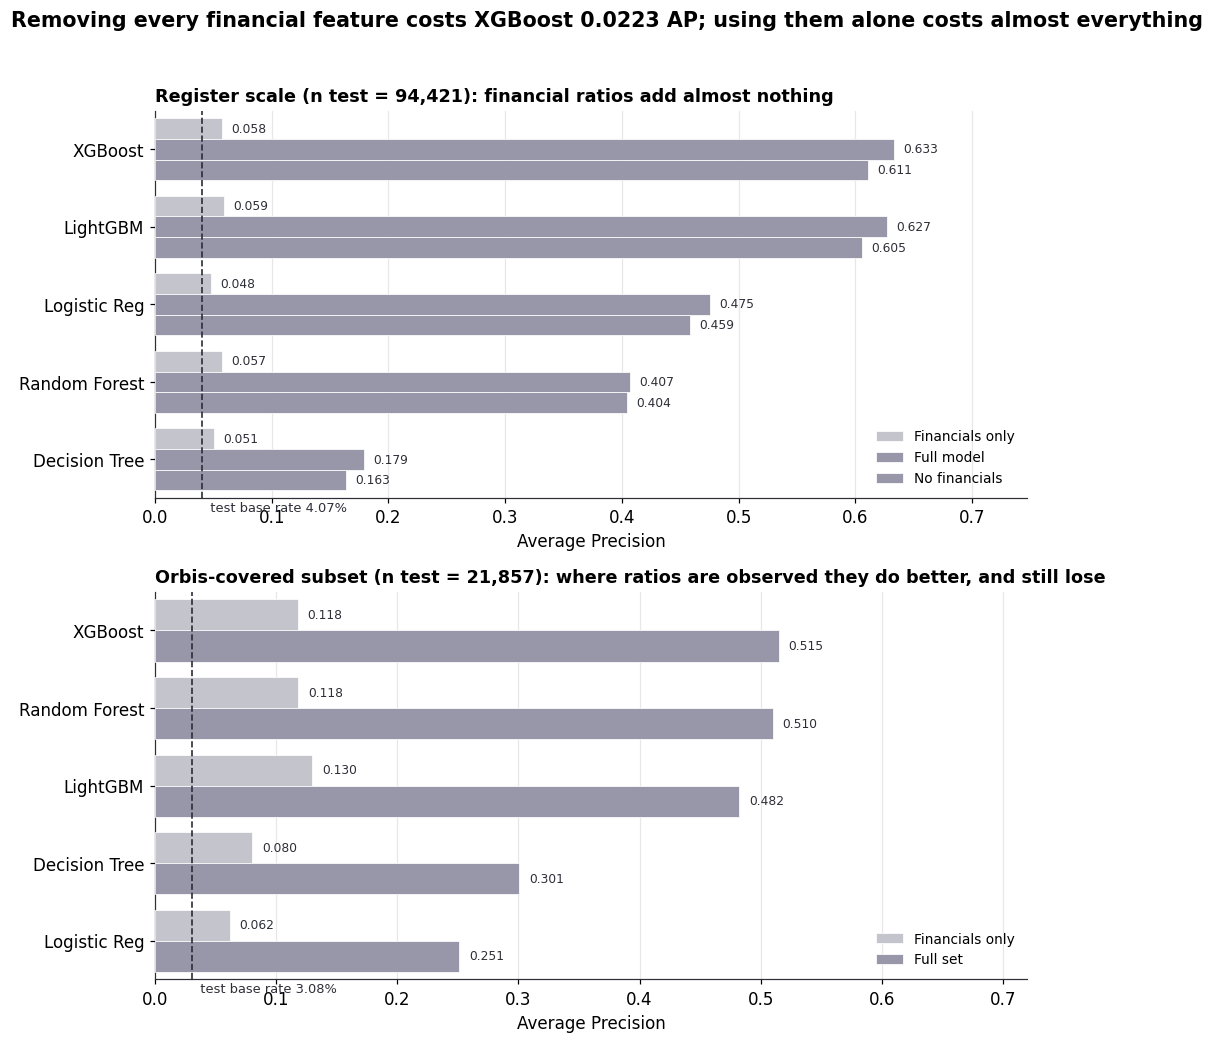

XGBoost register scale: full 0.6333 -> no financials 0.6110 (delta 0.0223)


In [40]:
ab1 = try_read("ablation_financial_experiment1.csv")
ab2 = try_read("ablation_financial_experiment2.csv")

if ab1 is None:
    print("ablation_financial_experiment1.csv not found. Figure skipped.")
else:
    def _panel(ax, df, order, title, base_rate, base_label):
        models = (df[df["feature_set"] == order[-1]]
                  .sort_values("avg_precision")["model"].tolist())
        if not models:
            models = df["model"].drop_duplicates().tolist()[::-1]
        n_sets = len(order)
        h = 0.8 / n_sets
        palette = {order[0]: LIGHT}
        rest = [SAFE, MID, GREY]
        for k, s in enumerate(order[1:]):
            palette[s] = rest[k % len(rest)]
        for k, s in enumerate(order):
            vals = [df.loc[(df["model"] == m) & (df["feature_set"] == s),
                           "avg_precision"].mean() for m in models]
            ypos = [i + (n_sets - 1 - k) * h - 0.4 + h/2 for i in range(len(models))]
            ax.barh(ypos, vals, height=h, color=palette[s], edgecolor="white",
                    linewidth=0.5, label=s, zorder=3)
            for y, v in zip(ypos, vals):
                if not np.isnan(v):
                    ax.text(v + 0.008, y, f"{v:.3f}", va="center", fontsize=8, color=CHARCOAL)
        ax.axvline(base_rate, color=REFLINE, linestyle="--", linewidth=1.1, zorder=4)
        ax.text(base_rate, -0.62, f"  {base_label}", fontsize=8.5,
                color=REFLINE, va="center")
        ax.set_yticks(range(len(models)))
        ax.set_yticklabels(models)
        ax.set_xlabel("Average Precision")
        ax.set_title(title, loc="left", fontsize=11.5)
        ax.set_xlim(0, max(0.72, df["avg_precision"].max() * 1.18))
        ax.grid(axis="y", visible=False)
        ax.margins(y=0.02)
        return ax

    fig, axes = plt.subplots(2, 1, figsize=(9.5, 9.5))

    o1 = [s for s in ["Financials only", "Full model", "No financials"]
          if s in set(ab1["feature_set"])]
    br1 = float(ab1["test_base_rate"].dropna().iloc[0]) if "test_base_rate" in ab1 else 0.0407
    _panel(axes[0], ab1, o1,
           f"Register scale (n test = {int(ab1['n_test'].iloc[0]):,}): financial ratios add almost nothing",
           br1, f"test base rate {br1:.2%}")
    axes[0].legend(loc="lower right", fontsize=9)

    if ab2 is not None:
        o2 = [s for s in ["Financials only", "Full set", "Full model", "No financials"]
              if s in set(ab2["feature_set"])]
        br2 = float(ab2["test_base_rate"].dropna().iloc[0]) if "test_base_rate" in ab2 else 0.0308
        _panel(axes[1], ab2, o2,
               f"Orbis-covered subset (n test = {int(ab2['n_test'].iloc[0]):,}): where ratios are observed they do better, and still lose",
               br2, f"test base rate {br2:.2%}")
        axes[1].legend(loc="lower right", fontsize=9)
    else:
        axes[1].text(0.5, 0.5, "ablation_financial_experiment2.csv not found",
                     ha="center", va="center", transform=axes[1].transAxes, color=GREY)
        axes[1].set_axis_off()

    _x = ab1[ab1["model"] == "XGBoost"].set_index("feature_set")["avg_precision"]
    _d = (_x["Full model"] - _x["No financials"]) if {"Full model", "No financials"} <= set(_x.index) else float("nan")
    fig.suptitle(f"Removing every financial feature costs XGBoost {_d:.4f} AP; using them alone costs almost everything",
                 x=0.01, ha="left", fontsize=13.5, fontweight="bold", y=0.995)
    add_source(fig, "Source: held-out temporal test set. Average Precision at the model's own "
                    "optimal threshold. Experiment 1 uses fixed hyperparameters across all "
                    "five algorithms for a controlled feature-set comparison, so the XGBoost "
                    "full-model AP of 0.6333 is not the Optuna-tuned headline of 0.6298. "
                    "Experiment 2 has no no-financials arm.")
    plt.tight_layout(rect=[0, 0, 1, 0.975])
    save_fig(fig, "fig_19_financial_ablation")
    plt.show()

    keep = [c for c in ["experiment", "population", "feature_set", "n_features",
                        "model", "avg_precision", "auc_roc"] if c in ab1.columns]
    out = pd.concat([ab1[keep]] + ([ab2[[c for c in keep if c in ab2.columns]]]
                                   if ab2 is not None else []), ignore_index=True)
    out.to_csv(TABLES_DIR / "financial_ablation_figure_data.csv", index=False)
    x = ab1[ab1["model"] == "XGBoost"].set_index("feature_set")["avg_precision"]
    if {"Full model", "No financials"} <= set(x.index):
        print(f"XGBoost register scale: full {x['Full model']:.4f} -> "
              f"no financials {x['No financials']:.4f} "
              f"(delta {x['Full model'] - x['No financials']:.4f})")


### Figure 5.13 - Anomaly detector against the permutation null (Deviation)

RQ3. Position against the null 95th percentile and against chance.

RQ3 source: anomaly_detector_comparison.csv
  saved: fig_20_anomaly_vs_null


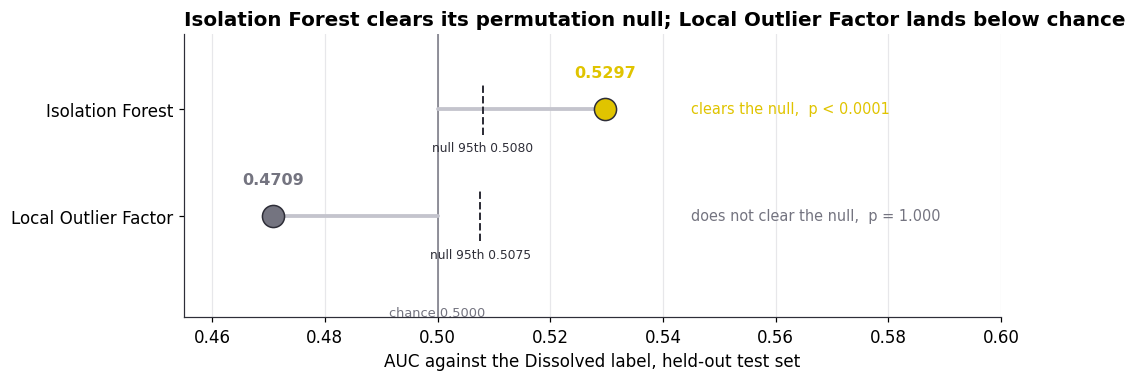

In [41]:
det = try_read("anomaly_detector_comparison.csv")
dcol = pick_col(det, "detector", "method", "model")
acol = pick_col(det, "observed_auc", "auc", "obs_auc")
ncol_ = pick_col(det, "null_95th", "null_95", "null95")
pcol_ = pick_col(det, "p_value", "pvalue", "p")

rows = []
if det is not None and dcol and acol and ncol_:
    rows = [(str(r[dcol]), float(r[acol]), float(r[ncol_]),
             float(r[pcol_]) if pcol_ else None) for _, r in det.iterrows()]
    rq3_src = "anomaly_detector_comparison.csv"
else:
    perm = try_read("if_permutation_test.csv")
    if perm is not None and perm.shape[1] >= 2:
        kv = {str(k).strip().lower(): v for k, v in zip(perm.iloc[:, 0], perm.iloc[:, 1])}
        def _get(*keys):
            for k in keys:
                if k in kv:
                    try:
                        return float(kv[k])
                    except (TypeError, ValueError):
                        return None
            return None
        a, n95, pv = _get("observed_auc", "auc"), _get("null_95th", "null_95"), _get("p_value", "p")
        if a is not None and n95 is not None:
            rows = [("Isolation Forest", a, n95, pv)]
            rq3_src = "if_permutation_test.csv (Isolation Forest only)"
            print("anomaly_detector_comparison.csv not found. Local Outlier Factor is computed")
            print("in 05_anomaly_detection.ipynb but not saved by an older run, so it is omitted")
            print("rather than typed in. Re-run 05 to restore the comparison.")

if not rows:
    raise FileNotFoundError(
        "Neither anomaly_detector_comparison.csv nor if_permutation_test.csv is readable. "
        "Run 05_anomaly_detection.ipynb. This figure is not drawn from stored constants.")
print(f"RQ3 source: {rq3_src}")

fig, ax = plt.subplots(figsize=(9.5, 3.6))
for i, (name, val, nl, pv) in enumerate(rows):
    y = len(rows) - 1 - i
    passes = val > nl
    col = RISK if passes else GREY
    ax.plot([0.5, val], [y, y], color=LIGHT, linewidth=2.5, zorder=2,
            solid_capstyle="round")
    ax.scatter([val], [y], s=210, color=col, edgecolor=CHARCOAL, linewidth=1.0,
               zorder=5)
    ax.text(val, y + 0.30, f"{val:.4f}", ha="center", fontsize=10.5, color=col,
            fontweight="bold")
    ax.plot([nl, nl], [y - 0.24, y + 0.24], color=REFLINE, linestyle="--", linewidth=1.3,
            zorder=4)
    ax.text(nl, y - 0.30, f"null 95th {nl:.4f}", ha="center", va="top", fontsize=8,
            color=REFLINE)
    tag = "clears the null" if passes else "does not clear the null"
    if pv is not None:
        tag += ",  p < 0.0001" if pv < 1e-4 else f",  p = {pv:.3f}"
    ax.text(0.545, y, tag, va="center", fontsize=9.5, color=col)
ax.axvline(0.5, color=GREY, linewidth=1.0, zorder=1)
ax.text(0.5, -0.85, "chance 0.5000", ha="center", fontsize=8.5, color=GREY, va="top")
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] for r in rows[::-1]])
ax.set_xlim(0.455, 0.60)
ax.set_ylim(-0.95, len(rows) - 0.3)
ax.set_xlabel("AUC against the Dissolved label, held-out test set")
ax.set_title("Isolation Forest clears its permutation null; Local Outlier Factor lands "
             "below chance", loc="left")
ax.grid(axis="y", visible=False)
add_source(fig, f"Source: {rq3_src}. Each detector is tested against its own null "
                f"distribution of 1,000 label shuffles, so the two thresholds are drawn "
                f"separately rather than shared. The 1,000 permuted values were not "
                f"retained, so the null appears as its 95th percentile rather than as a "
                f"distribution. Isolation Forest is significant; the effect size is three "
                f"points above chance.")
plt.tight_layout()
save_fig(fig, "fig_20_anomaly_vs_null")
plt.show()
pd.DataFrame([{"detector": n, "auc": v, "null_95th": nl, "clears_null": v > nl}
              for n, v, nl, _ in rows]).to_csv(
    TABLES_DIR / "anomaly_detector_validation.csv", index=False)


### Figure 5.14 - Lead time by pre-dissolution window (Distribution)

RQ2. The decay of detection rate as the window widens.

RQ2 source: rq2_lead_time_windows.csv, cohort: test and prospective combined
  saved: fig_21_lead_time_windows


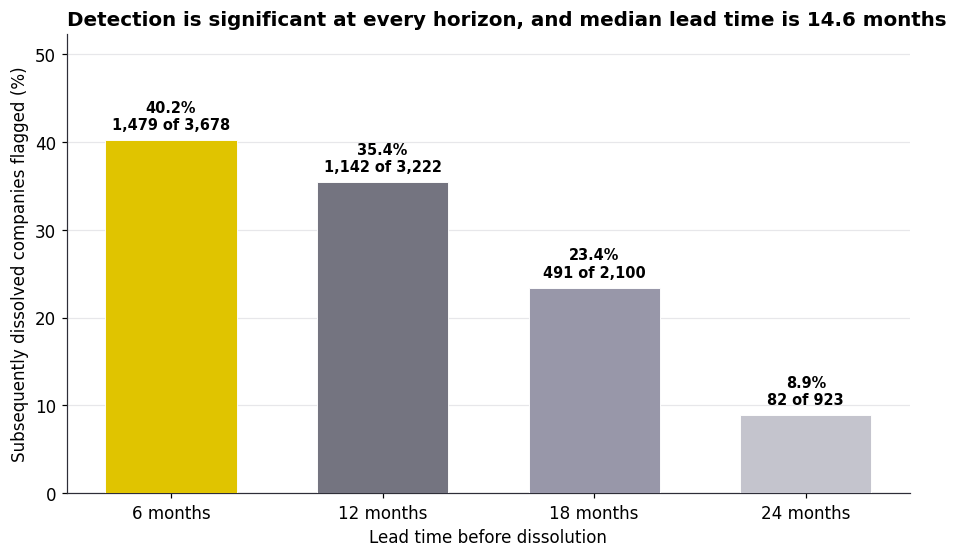

In [42]:
rq2 = try_read("rq2_lead_time_windows.csv")
wcol = pick_col(rq2, "window_months", "window", "months")
scol = pick_col(rq2, "flagged_share", "flag_rate", "flagging_rate", "share")
if rq2 is None or not (wcol and scol):
    raise FileNotFoundError(
        "rq2_lead_time_windows.csv not found. Run 05_anomaly_detection.ipynb, which computes "
        "and writes it. This figure is not drawn from stored constants.")

ccol = pick_col(rq2, "cohort")
if ccol is not None and (rq2[ccol].astype(str) == "test and prospective combined").any():
    r2 = rq2[rq2[ccol].astype(str) == "test and prospective combined"].copy()
    cohort_label = "test and prospective combined"
else:
    r2 = rq2.copy()
    cohort_label = "all rows in the file"
    print("No 'test and prospective combined' rows found; plotting every row in the file.")
r2 = r2.sort_values(wcol)
windows = [int(w) for w in r2[wcol]]
vals = [float(v)*100 if float(v) <= 1 else float(v) for v in r2[scol]]
ncol = pick_col(rq2, "n_companies", "n", "n_total")
fcol = pick_col(rq2, "n_flagged", "flagged")
mcol = pick_col(rq2, "median_lead_months", "median_lead")
med = round(float(r2[mcol].dropna().iloc[0]), 1) if mcol and r2[mcol].notna().any() else None
rq2_src = f"rq2_lead_time_windows.csv, cohort: {cohort_label}"
print(f"RQ2 source: {rq2_src}")

shade = [RISK, GREY, MID, LIGHT]
fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar([f"{w} months" for w in windows], vals,
              color=[shade[i % len(shade)] for i in range(len(windows))],
              edgecolor="white", linewidth=0.6, width=0.62, zorder=3)
for i, (b, v) in enumerate(zip(bars, vals)):
    lab = f"{v:.1f}%"
    if r2 is not None and ncol and fcol:
        lab += f"\n{int(r2[fcol].iloc[i]):,} of {int(r2[ncol].iloc[i]):,}"
    ax.text(b.get_x()+b.get_width()/2, v+0.9, lab, ha="center", va="bottom",
            fontsize=9.5, fontweight="bold")
ax.set_ylabel("Subsequently dissolved companies flagged (%)")
ax.set_xlabel("Lead time before dissolution")
ax.set_ylim(0, max(vals)*1.3)
ax.set_title("Detection is significant at every horizon"
             + (f", and median lead time is {med} months" if med else ""), loc="left")
ax.grid(axis="x", visible=False)
add_source(fig, f"Source: {rq2_src}. Companies subsequently dissolved, scored against the "
                f"95th-percentile calibrated Stage 1 threshold, test and prospective "
                f"partitions combined. Each window is a one-sided binomial test against the "
                f"tier's nominal 5% rate and is significant. Windows are nested, not "
                f"cumulative bands: a company at 20 months counts in the 6, 12 and 18 month "
                f"rows.")
plt.tight_layout()
save_fig(fig, "fig_21_lead_time_windows")
plt.show()


### Figure 5.18 - Tier validation against the register (Deviation)

Independent confirmation: the share of each tier that subsequently appears on the CRO register as exiting, against the cohort base rate.

Tier confirmation source: tier_register_confirmation.csv
  saved: fig_18_tier_confirmation


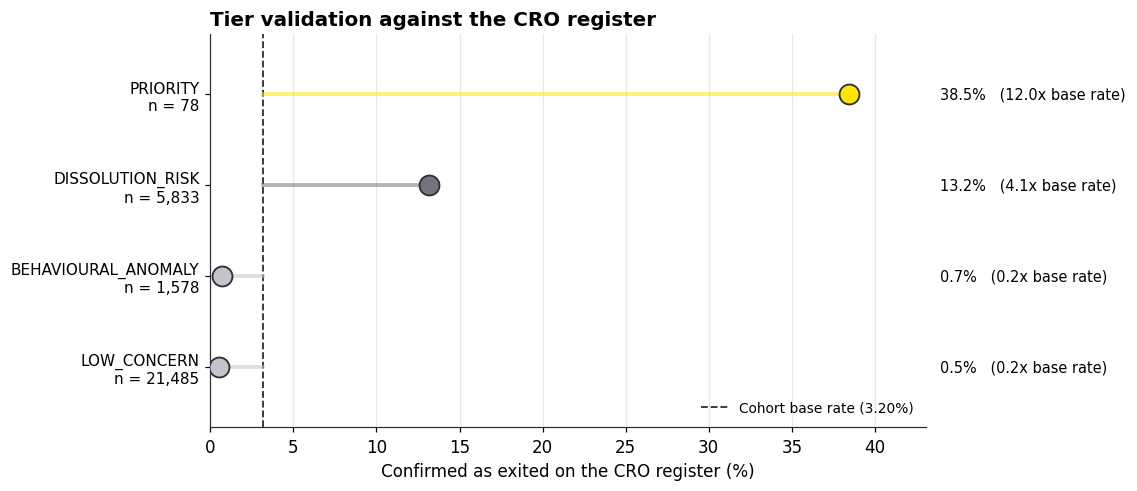

In [43]:
tcf = try_read("tier_register_confirmation.csv")
tcol_ = pick_col(tcf, "tier", "combined_risk_tier", "risk_tier")
rcol_ = pick_col(tcf, "confirm_rate", "confirmed_rate", "rate")
if tcf is None or not (tcol_ and rcol_):
    raise FileNotFoundError(
        "tier_register_confirmation.csv not found. Run 05_anomaly_detection.ipynb, which "
        "computes and writes it. This figure is not drawn from stored constants.")
cd = pd.DataFrame({"tier": tcf[tcol_].astype(str).str.replace("BEHAVIORAL", "BEHAVIOURAL", regex=False),
                   "confirm_rate": tcf[rcol_].astype(float)})
bcol = pick_col(tcf, "cohort_base_rate", "base_rate")
ncol2 = pick_col(tcf, "n", "n_companies")
if bcol is None:
    raise ValueError("tier_register_confirmation.csv has no cohort_base_rate column. The "
                     "reference line has no source, so the figure is not drawn.")
tb = float(tcf[bcol].iloc[0])
if ncol2:
    cd["n"] = tcf[ncol2].values
tier_src = "tier_register_confirmation.csv"
print(f"Tier confirmation source: {tier_src}")

cd["lift"] = cd["confirm_rate"]/tb
cd = cd.sort_values("confirm_rate")
cd.to_csv(TABLES_DIR / "tier_confirmation_figure_data.csv", index=False)

TIER_COL = {"PRIORITY": ACCENT, "DISSOLUTION_RISK": GREY,
            "BEHAVIOURAL_ANOMALY": LIGHT, "BEHAVIORAL_ANOMALY": LIGHT,
            "LOW_CONCERN": LIGHT}
fig, ax = plt.subplots(figsize=(10.5, 4.6))
for i, (_, r) in enumerate(cd.iterrows()):
    c = TIER_COL.get(str(r["tier"]).upper(), MID)
    x = r["confirm_rate"]*100
    ax.plot([tb*100, x], [i, i], color=c, linewidth=2.5, alpha=0.55, zorder=2)
    ax.scatter(x, i, s=170, color=c, edgecolor=CHARCOAL, linewidth=1.2, zorder=3)
    ax.text(1.02, i, f"{r['confirm_rate']:.1%}   ({r['lift']:.1f}x base rate)",
            transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=9.5)
ax.axvline(tb*100, color=REFLINE, linestyle="--", linewidth=1.2, zorder=1,
           label=f"Cohort base rate ({tb:.2%})")
ax.set_yticks(range(len(cd)))
ax.set_yticklabels([f"{t}\nn = {int(n):,}" for t, n in zip(cd["tier"], cd["n"])]
                   if "n" in cd.columns else cd["tier"], fontsize=10)
ax.set_xlabel("Confirmed as exited on the CRO register (%)")
ax.set_title("Tier validation against the CRO register", loc="left")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, max(cd["confirm_rate"])*100*1.12)
ax.margins(y=0.22)
add_source(fig, f"Source: {tier_src}. A lower bound, since register updates lag a "
                f"company's actual failure. This is an independent check: the register "
                f"outcome was not available to the model at the observation date.")
plt.tight_layout()
save_fig(fig, "fig_18_tier_confirmation")
plt.show()


### Figure 5.19 - Entity composition by risk tier (Part-to-whole)

What each tier is actually made of, as shares rather than counts.

  saved: fig_22_entity_by_tier


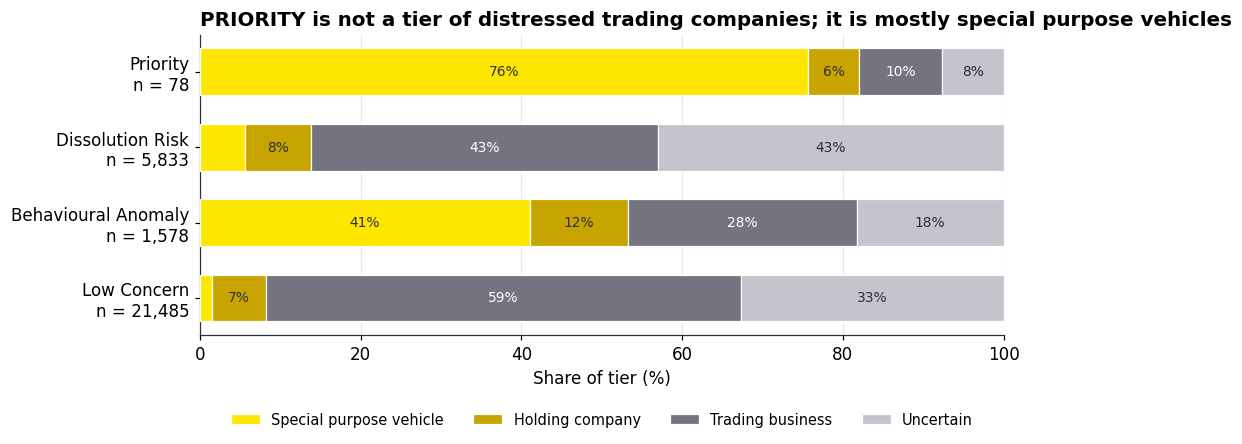

                     special_purpose_vehicle  holding_company  trading_business  uncertain
combined_risk_tier                                                                        
PRIORITY                                75.6              6.4              10.3        7.7
DISSOLUTION_RISK                         5.6              8.2              43.2       43.0
BEHAVIOURAL_ANOMALY                     41.0             12.3              28.4       18.3
LOW_CONCERN                              1.4              6.8              59.1       32.7


In [44]:
ent = try_read("entity_type_by_tier.csv")
tcol = pick_col(ent, "combined_risk_tier", "risk_tier", "tier")
if ent is None or tcol is None:
    print("entity_type_by_tier.csv not found. Figure skipped.")
else:
    segs = [c for c in ["special_purpose_vehicle", "holding_company",
                        "trading_business", "uncertain"] if c in ent.columns]
    nice = {"special_purpose_vehicle": "Special purpose vehicle",
            "holding_company": "Holding company",
            "trading_business": "Trading business",
            "uncertain": "Uncertain"}
    cols = {"special_purpose_vehicle": HUE_A, "holding_company": HUE_C,
            "trading_business": HUE_B, "uncertain": LIGHT}
    e = ent.copy()
    e[tcol] = (e[tcol].astype(str).str.upper().str.strip()
               .str.replace("BEHAVIORAL", "BEHAVIOURAL", regex=False))
    order = [t for t in ["PRIORITY", "DISSOLUTION_RISK", "BEHAVIOURAL_ANOMALY", "LOW_CONCERN"] if t in set(e[tcol])]
    e = e.set_index(tcol).loc[order]
    tot = e[segs].sum(axis=1)
    share = e[segs].div(tot, axis=0) * 100

    fig, ax = plt.subplots(figsize=(9.5, 4.4))
    left = np.zeros(len(e))
    ypos = np.arange(len(e))[::-1]
    for s in segs:
        ax.barh(ypos, share[s].values, left=left, color=cols[s], label=nice[s],
                edgecolor="white", linewidth=0.8, height=0.62, zorder=3)
        for y, (l, w) in zip(ypos, zip(left, share[s].values)):
            if w >= 6:
                ax.text(l + w/2, y, f"{w:.0f}%", ha="center", va="center", fontsize=9,
                        color="white" if cols[s] == HUE_B else CHARCOAL)
        left = left + share[s].values
    ax.set_yticks(ypos)
    ax.set_yticklabels([f"{t.replace('_', ' ').title()}\nn = {int(n):,}"
                        for t, n in zip(e.index, tot)])
    ax.set_xlabel("Share of tier (%)")
    ax.set_xlim(0, 100)
    ax.set_title("PRIORITY is not a tier of distressed trading companies; it is mostly "
                 "special purpose vehicles", loc="left")
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=4, fontsize=9.5)
    add_source(fig, "Source: LLM entity classifier over the prospective cohort "
                    "(n = 28,974). Shares within each tier, so tiers of very different "
                    "size are comparable. 'Uncertain' is a genuine model judgement, "
                    "driven mainly by uninformative company names, not a parse failure.")
    plt.tight_layout()
    save_fig(fig, "fig_22_entity_by_tier")
    plt.show()
    share.round(1).to_csv(TABLES_DIR / "entity_type_share_by_tier.csv")
    print(share.round(1).to_string())


## Figure inventory

In [45]:
print(f"Figures generated: {len(FIG_LOG)}\n")
for i, n in enumerate(FIG_LOG, 1):
    print(f"  {i:2d}. {n}")

pd.DataFrame({"n": range(1, len(FIG_LOG)+1), "figure": FIG_LOG}).to_csv(
    TABLES_DIR / "figure_inventory.csv", index=False)

notes_df = pd.DataFrame(FIG_NOTES)
notes_df.insert(0, "n", range(1, len(notes_df)+1))
notes_df.to_csv(TABLES_DIR / "figure_notes.csv", index=False)

print(f"\nPNG (300 dpi) and SVG written to: {FIGURES_DIR}")
print(f"Figure data CSVs written to: {TABLES_DIR}")
print(f"\nCaption notes for the manuscript: {TABLES_DIR / 'figure_notes.csv'}")
print("Figures carry no baked-in source line; paste the note into the caption instead.")
print("Set SHOW_SOURCE_NOTES = True in the setup cell to draw them on the images.")

Figures generated: 23

   1. fig_01_completeness
   2. fig_02_effect_sizes
   3. fig_03_top_feature_distributions
   4. fig_04_binary_odds
   5. fig_05_sector_risk
   6. fig_06_age_curve
   7. fig_07_county_risk
   8. fig_08_correlation
   9. fig_09_distribution_diagnostics
  10. fig_10_model_ap
  11. fig_11_model_auc
  12. fig_12_pr_curve
  13. fig_13_roc_curve
  14. fig_14_calibration
  15. fig_15_ks_separation
  16. fig_23_triage_gains
  17. fig_16_shap_importance
  18. fig_17_shap_direction
  19. fig_19_financial_ablation
  20. fig_20_anomaly_vs_null
  21. fig_21_lead_time_windows
  22. fig_18_tier_confirmation
  23. fig_22_entity_by_tier

PNG (300 dpi) and SVG written to: E:\Trinity College Dublin\MSc_Business_Analytics\DISSERTATION\ISD_V17\outputs\figures
Figure data CSVs written to: E:\Trinity College Dublin\MSc_Business_Analytics\DISSERTATION\ISD_V17\outputs\tables

Caption notes for the manuscript: E:\Trinity College Dublin\MSc_Business_Analytics\DISSERTATION\ISD_V17\outputs\t

## Figure directory reconciliation

Confirms that every image file in the figure directory was produced by this run, so a figure from a superseded version cannot be pasted into the manuscript by mistake.

In [46]:
import shutil, time

expected = set()
for n in FIG_LOG:
    expected.add(f"{n}.png")
    if SAVE_SVG:
        expected.add(f"{n}.svg")

on_disk = {p.name for p in FIGURES_DIR.iterdir()
           if p.is_file() and p.suffix.lower() in {".png", ".svg", ".pdf", ".jpg", ".jpeg"}}
orphans = sorted(on_disk - expected)

print(f"Figure files written this run : {len(expected)}")
print(f"Image files in directory      : {len(on_disk)}")

if orphans:
    quarantine = FIGURES_DIR / "_superseded"
    quarantine.mkdir(exist_ok=True)
    stamp = time.strftime("%Y%m%d_%H%M%S")
    print(f"\nNot produced by this run ({len(orphans)}). Moved to {quarantine.name}/:")
    for f in orphans:
        target = quarantine / f"{stamp}__{f}"
        shutil.move(str(FIGURES_DIR / f), str(target))
        print(f"  {f}")
    print("\nThese are leftovers from earlier versions of the notebook. Nothing is"
          "\ndeleted; if one is still wanted, move it back. Every remaining file in"
          "\nthe figure directory was produced by this run.")
else:
    print("\nNo orphans. Every image file in the directory was produced by this run.")

if SAVE_SVG:
    missing_svg = sorted(f"{n}.svg" for n in FIG_LOG if not (FIGURES_DIR / f"{n}.svg").exists())
    if missing_svg:
        print(f"\nSVG expected but absent: {missing_svg}")


Figure files written this run : 23
Image files in directory      : 23

No orphans. Every image file in the directory was produced by this run.
